This code is used to calculate the cost analysis of the EV charging station at UCSD
With the funding from TotalEnergies
Edited by Yizhan Gu
Email: yig031@ucsd.edu

In [45]:
import os
import os.path
import pandas as pd
import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
from datetime import timedelta
from datetime import datetime
import time
from time import process_time
import calendar
import holidays
from pathlib import Path
from random import choices
import cvxpy as cp
import scs
#import sys
#sys.path.insert(0, 'C:/Users/Anne/Desktop/Total/Code\Python/')
from forecast_ED_PD import KnownUser, UnKnownUser
import glob


Time_Run_Start = process_time()


Blue1 = (0.341, 0.82, 1)
Blue2 = (0.341, 0.592, 1)
Blue3 = (0.365, 0.365, 1)
Blue4 = (0, 0, 0.89)
Blue5 = (0, 0, 0.639)
Blue6 = (0, 0.161, 0.42)

Red1 = (1, 0.725, 0.635)
Red2 = (1, 0.6, 0.467)
Red3 = (1, 0.361, 0.353)
Red4 = (1, 0.153, 0.137)
Red5 = (0.812, 0.016, 0)
Red6 = (0.541, 0.008, 0)




#################################################################################
# Parameters
#################################################################################


dt_m_EV = 15
dt_h = dt_m_EV/60
interval = timedelta(minutes=dt_m_EV)
unit = dt_h

# Energy Prices-AL-TOU:

# Summer: off-peak period energy charge rate $0.10679/kW h
#         On-peak period energy charge rate $0.12628/kW h
# Winter: off-peak period energy charge rate $0.09506/kW h
#         On-peak period energy charge rate $0.10626/kW h
c_e_TOU_AL = np.ones((96, 1))*0.10679
c_e_TOU_AL[16*4:21*4] = 0.12628


# Demand Charges
c_NCD = 24.48  #24.48*0.25=6.12
c_PD = 19.14 + 9.78

# Tax
c_tax_DWR = 0.00580                               # x Total kWh
c_tax_oEESbo_Franchise = 0.0688 * c_tax_DWR       # x Total kWh
c_tax_CA_Surcharge = 0.00030                      # x Total kWh
c_tax_CA_Regulatory = 0.00058                     # x Total kWh
# x Total Bill (UDC+Commodity)
c_tax_SD_Franchise = 0.0578

c_tax_all = c_tax_DWR + c_tax_oEESbo_Franchise + c_tax_CA_Surcharge + c_tax_CA_Regulatory




#################################################################################
# Different service level during ELRP hours
#################################################################################


# manual type in real ELRP event days in year 2022
ELRP_2022 = [datetime(2022, 8, 31), datetime(2022, 9, 1), datetime(2022, 9, 3), \
             datetime(2022, 9, 4), datetime(2022, 9, 5),  datetime(2022, 9, 6), \
             datetime(2022, 9, 7), datetime(2022, 9, 8),  datetime(2022, 9, 9)]


Holidays = holidays.US()




#################################################################################
# Choose the forecast and the settings of this case
#################################################################################


# On the quarterly reviw slides, the four scenarios are as follows
# PFCT:   Fc_SessionkWh == 'PerfectSessionkWh'    , Fc_NumbEV=='PerfectNumbEV'    , Fc_AtArrival =='PerfectatArrival'
# PSIS-a: Fc_SessionkWh == 'PersistenceSessionkWh', Fc_NumbEV=='PerfectNumbEV'    , Fc_AtArrival =='PerfectatArrival'
# PSIS-b: Fc_SessionkWh == 'PersistenceSessionkWh', Fc_NumbEV=='PersistenceNumbEV', Fc_AtArrival =='PerfectatArrival'
# PSIS-c: Fc_SessionkWh == 'PersistenceSessionkWh', Fc_NumbEV=='PersistenceNumbEV', Fc_AtArrival =='MLatArrival'

Numb_EVs = 0
Numb_AbsDiffEVs = 0

Fc_SessionkWh = 'PerfectSessionkWh'  # 'PerfectSessionkWh' #'PersistenceSessionkWh'
Fc_NumbEV = 'PerfectNumbEV'          # 'PerfectNumbEV'     #'PersistenceNumbEV'
Fc_AtArrival = 'PerfectatArrival'    # 'PerfectatArrival'  #'MLatArrival'
DAM = 1 # 1/0: w/o day-ahead market participation (Demand Response)


#always run both the base case (no demand reduction) and the case with service reduction
Cases = ['Base', 'Case1']

/var/folders/pj/537pcfgn4672xs4gjs0w444w0000gn/T/ipykernel_50032/2516601868.py:9: DtypeWarning: Columns (5,6,8,11,12,21,22,23,25,30,35) have mixed types. Specify dtype option on import or set low_memory=False.
  Data = pd.read_csv(filename_Input)
/var/folders/pj/537pcfgn4672xs4gjs0w444w0000gn/T/ipykernel_50032/2516601868.py:39: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-parsing.html. You can safely remove this argument.
  Data['Interval start'] = pd.to_datetime(Data['Interval start'], errors='coerce', infer_datetime_format=True)
/var/folders/pj/537pcfgn4672xs4gjs0w444w0000gn/T/ipykernel_50032/2516601868.py:40: UserWarning: The argument 'infer_datetime_format' is deprecated and will be removed in a future version. A strict version of it is now the default, see https://pandas.pydata.org/pdeps/0004-consistent-to-datetime-p

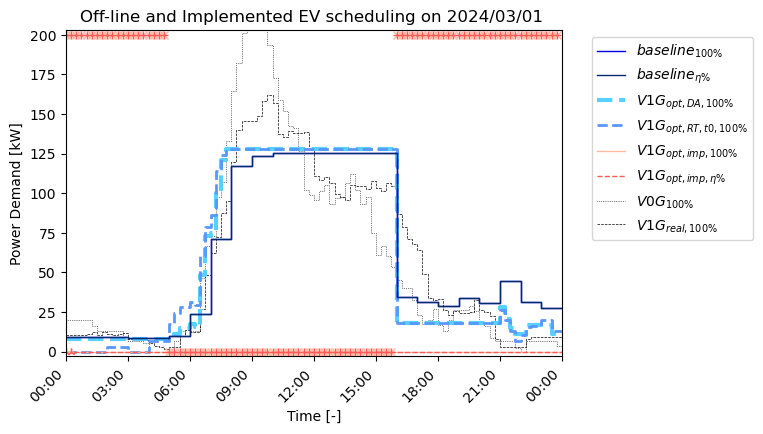

/var/folders/pj/537pcfgn4672xs4gjs0w444w0000gn/T/ipykernel_50032/2516601868.py:1676: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([Baseline_base, Baseline_case1, Opt_DA, Opt_t0, Opt_Imp_base, Opt_Imp_case1, V0G, V1G,\


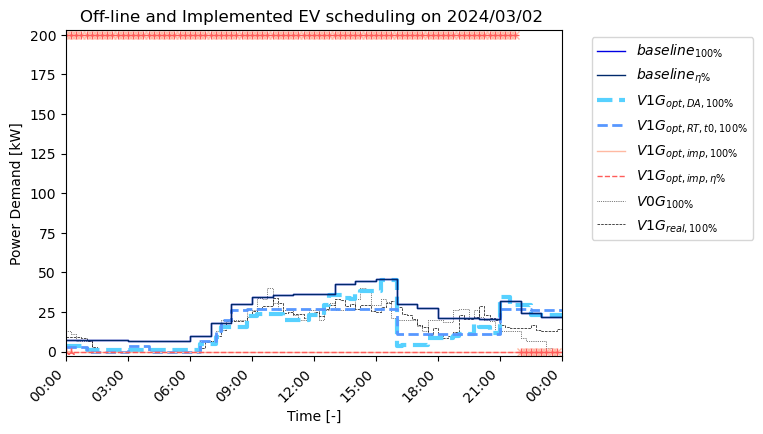

/var/folders/pj/537pcfgn4672xs4gjs0w444w0000gn/T/ipykernel_50032/2516601868.py:1676: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([Baseline_base, Baseline_case1, Opt_DA, Opt_t0, Opt_Imp_base, Opt_Imp_case1, V0G, V1G,\


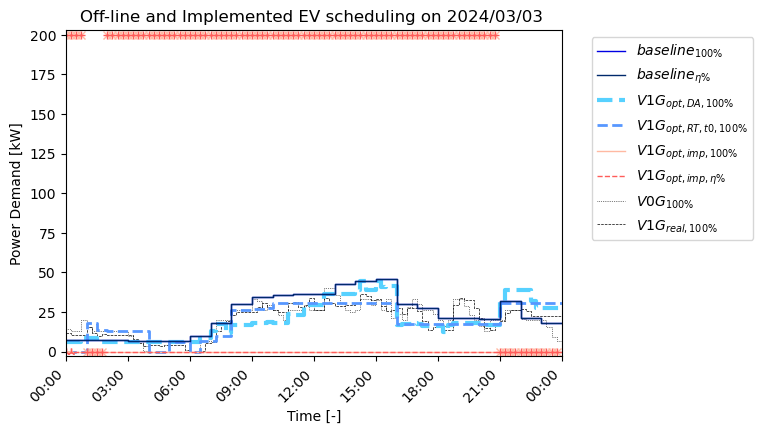

/var/folders/pj/537pcfgn4672xs4gjs0w444w0000gn/T/ipykernel_50032/2516601868.py:1676: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([Baseline_base, Baseline_case1, Opt_DA, Opt_t0, Opt_Imp_base, Opt_Imp_case1, V0G, V1G,\


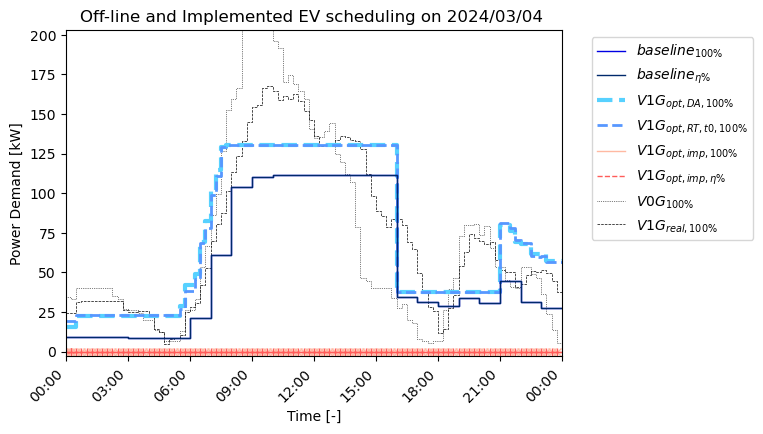

/var/folders/pj/537pcfgn4672xs4gjs0w444w0000gn/T/ipykernel_50032/2516601868.py:1676: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([Baseline_base, Baseline_case1, Opt_DA, Opt_t0, Opt_Imp_base, Opt_Imp_case1, V0G, V1G,\


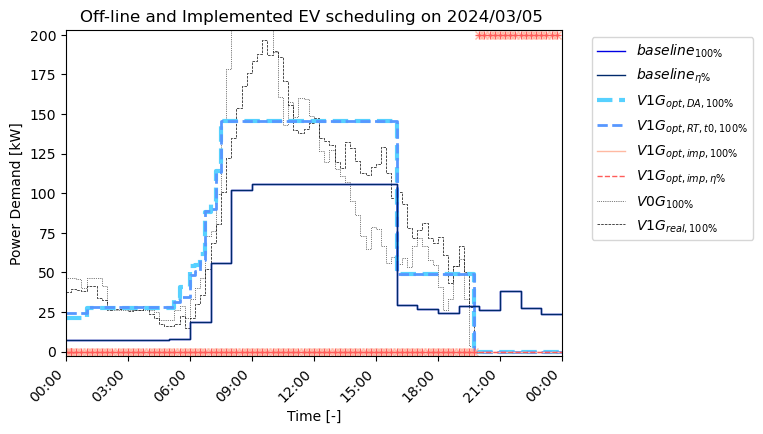

/var/folders/pj/537pcfgn4672xs4gjs0w444w0000gn/T/ipykernel_50032/2516601868.py:1676: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([Baseline_base, Baseline_case1, Opt_DA, Opt_t0, Opt_Imp_base, Opt_Imp_case1, V0G, V1G,\


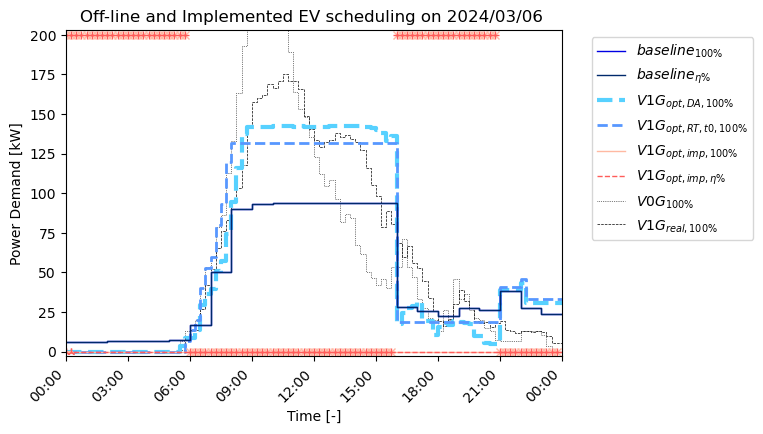

/var/folders/pj/537pcfgn4672xs4gjs0w444w0000gn/T/ipykernel_50032/2516601868.py:1676: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([Baseline_base, Baseline_case1, Opt_DA, Opt_t0, Opt_Imp_base, Opt_Imp_case1, V0G, V1G,\


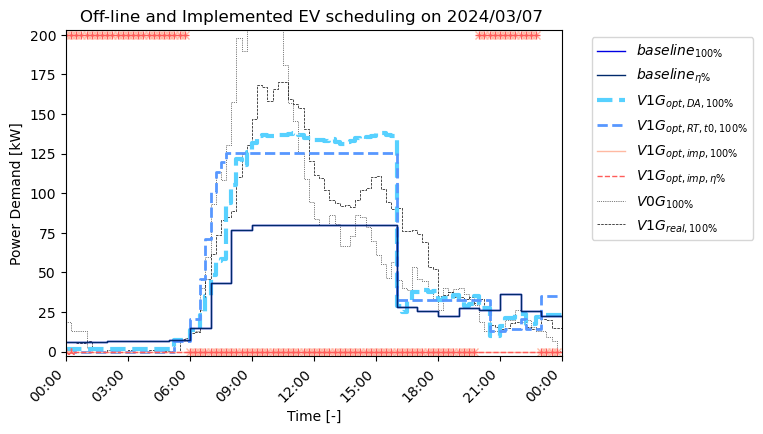

/var/folders/pj/537pcfgn4672xs4gjs0w444w0000gn/T/ipykernel_50032/2516601868.py:1676: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([Baseline_base, Baseline_case1, Opt_DA, Opt_t0, Opt_Imp_base, Opt_Imp_case1, V0G, V1G,\


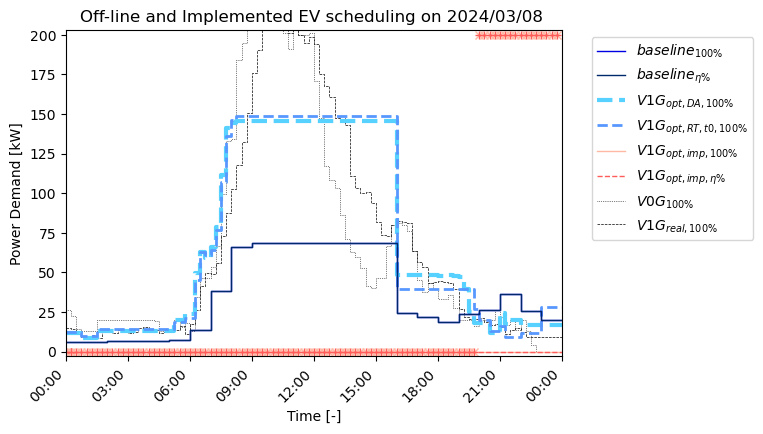

/var/folders/pj/537pcfgn4672xs4gjs0w444w0000gn/T/ipykernel_50032/2516601868.py:1676: UserWarning: Legend does not support handles for list instances.
A proxy artist may be used instead.
See: https://matplotlib.org/stable/users/explain/axes/legend_guide.html#controlling-the-legend-entries
  plt.legend([Baseline_base, Baseline_case1, Opt_DA, Opt_t0, Opt_Imp_base, Opt_Imp_case1, V0G, V1G,\


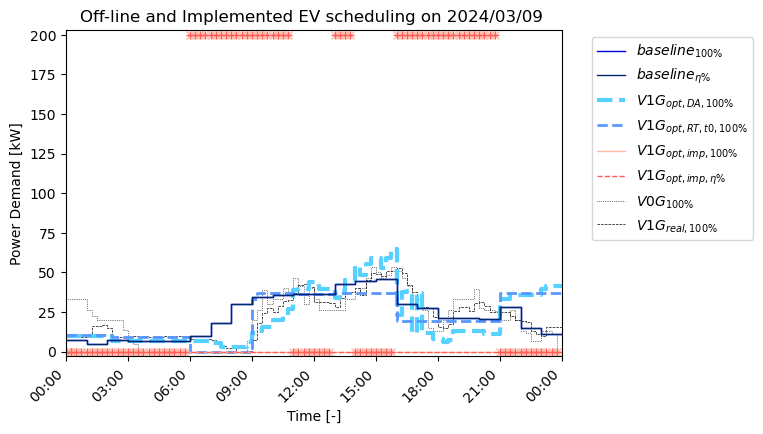

FileNotFoundError: [Errno 2] No such file or directory: ''

In [52]:

#################################################################################
# Read Data
#################################################################################



filename_Input = 'UCSD_AllSites_Merge_Eta_20210504_20230129_v2.csv'
filename_Input = 'UCSD_AllSites_Merge_PostProcessedSession_20210504_20240930.csv' 
Data = pd.read_csv(filename_Input)
#Filter sessions for ones that only occurred at Hopkins parking structure 
#Data = Data[Data['Site'].str.contains('Hopkins')]

#Vehicles_all = Data['Vehicle'].unique()
# 307 cars


# only when participate in DA DR market, we need the baseline and the LMP
# =============================================================================
# if DAM == 1:    
#     dir_Input = os.path.join( 'C:/Users/Anne/Desktop/Total/Data/EV_PF_UCSD/Flexibility/Dispatch' )
#     filename_Input = dir_Input + '/Perfect_SessionkWh/2022_Perfect_SessionkWhFc_MonthlyTh_Eta_v0_test.csv'
#     #filename_Input = dir_Input + '/2022_'+Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'_MonthlyTh_Eta_v5_2.csv'
#     Dispatch_2022 = pd.read_csv(filename_Input)    
#     
#     # make sure dropping the earlier data for duplicated rows    
#     Dispatch_2022['Interval start'] = pd.to_datetime(Dispatch_2022['Interval start'])
#     Dispatch_2022 = Dispatch_2022.drop_duplicates('Interval start',keep='last')
# =============================================================================

    


#################################################################################
# Data Processing
#################################################################################


# Convert to datetime
Data['Interval start'] = pd.to_datetime(Data['Interval start'], errors='coerce', infer_datetime_format=True)
Data['Interval end'] = pd.to_datetime(Data['Interval end'], errors='coerce', infer_datetime_format=True)
Data['Session start'] = pd.to_datetime(Data['Session start'], errors='coerce', infer_datetime_format=True)
Data['Session end'] = pd.to_datetime(Data['Session end'], errors='coerce', infer_datetime_format=True)
#Data = Data.dropna(subset=['Interval start', 'Interval end', 'Session start', 'Session end'])

#Concat 'Car_' Column 
#Data['User'] = Data['User'].astype(str)
#Data['Vehicle'] = Data['Vehicle'].astype(str)
#Create 'Car_' column type string to concate vehicle ID (number) and User email 
#Data['Car_'] = Data['User'].str.cat(others=Data['Vehicle'], sep='.', na_rep=None, join='left')
#print(Data['Car_'])
Data['Car_'] = Data['10-digit UID'].astype(str)

if Fc_AtArrival == 'MLatArrival':
    User_Data = pd.read_csv ('Driver_Table.csv')
    #User_Data = pd.read_csv ('C:/Users/Anne/Desktop/Total/Code/Avik/Forecasting/ML_based/Driver Table and Sessions/Driver_Table.csv')
    User_known = User_Data['driver_id'][User_Data['TotSession']>10].unique()
    UserNoBess = []

#################################################################################
# Choose the 'Date' you want to analyze
#################################################################################


year = 2024


# create weekdays (excluding holidays) and weekends (including holidays) lists
datetime(year,1,1) in Holidays
start_ind_Y = datetime(year,2,1)
end_ind_Y = datetime(year,7,31)
DateSeries_ThisY = []
while start_ind_Y < end_ind_Y:
    DateSeries_ThisY.append(start_ind_Y)
    start_ind_Y += timedelta(hours=24)

DateSeries_ThisY = pd.Series(DateSeries_ThisY) #365 days
Y_Weekends = DateSeries_ThisY[DateSeries_ThisY.dt.dayofweek>=5] #105 days
Y_Holidays = DateSeries_ThisY[DateSeries_ThisY.isin(Holidays)] #13 days

Y_WeekendsWH = pd.concat([Y_Weekends,Y_Holidays],axis=0).drop_duplicates(keep='first', inplace=False).sort_values(axis=0, ascending=True).reset_index(drop=True) #115 days
Y_WeekdaysWOH = DateSeries_ThisY[~(DateSeries_ThisY.isin(Y_WeekendsWH))].sort_values(axis=0, ascending=True).reset_index(drop=True) #250 days




for month in np.array(range(1))+3:
    #month = 3
    num_days = calendar.monthrange(year,month)[1] 
    
   
    M_Th_NCD = [0 for _ in range(len(Cases)+1)]
    M_Th_PD = [0 for _ in range(len(Cases)+1)]
    M_Th_NCD_list = [[] for _ in range(len(Cases)+1)]
    M_Th_PD_list = [[] for _ in range(len(Cases)+1)]
    M_Th_NCD_list_96 = [[] for _ in range(len(Cases)+1)]
    M_Th_PD_list_96 = [[] for _ in range(len(Cases)+1)]
    
    
    M_V0G = pd.DataFrame()
    M_V1G = pd.DataFrame()
    M_Opt_Offline = pd.DataFrame()
    M_Opt_Imp = [pd.DataFrame() for _ in range(len(Cases))] #pd.DataFrame()
    M_t = pd.DataFrame()
    
    M_ED_V0G = []
    M_ED_V1G = []
    M_ED_Opt_DA = []
    M_ED_Opt_t0 = []
    M_ED_Opt_base = []
    M_ED_Opt_case1 = []
    
    
    #only calculate the V1G baseline when there's market participation
    if DAM == 1:
        #M_baseline_V0G = pd.DataFrame()
        M_baseline_Opt = pd.DataFrame()

    # Run case PSIS-c-test1 with Eta% only on Dec 1, 9, 14, and 22 
    for Day in np.array(range(num_days))+1: #np.array(range(1))+1: 
        # Day = 1

        
        
        TheDate_Day0 = datetime(year, month, Day)   
        TheDate_Day0_Start = TheDate_Day0 + timedelta(seconds=0)
        TheDate_Day0_End = TheDate_Day0 + timedelta(hours=24)
# =============================================================================
#     if 1 > 0:   
#         TheDate_Day0 = datetime(2022, 1, 1)
# =============================================================================


        
        if len(Y_WeekdaysWOH[Y_WeekdaysWOH==TheDate_Day0])>0: 
            Order = Y_WeekdaysWOH[Y_WeekdaysWOH==TheDate_Day0].index  
            TheDate_Dayb1 = Y_WeekdaysWOH[Order-1].iloc[0]
            TheDate_Dayb2 = Y_WeekdaysWOH[Order-2].iloc[0]
            TheDate_Dayb3 = Y_WeekdaysWOH[Order-3].iloc[0]
        else:
            Order = Y_WeekendsWH[Y_WeekendsWH==TheDate_Day0].index  
            TheDate_Dayb1 = Y_WeekendsWH[Order-1].iloc[0]
            TheDate_Dayb2 = Y_WeekendsWH[Order-2].iloc[0]
            TheDate_Dayb3 = Y_WeekendsWH[Order-3].iloc[0]
            

        
        TheDate_Dayb1_Start = TheDate_Dayb1 + timedelta(seconds=0)
        TheDate_Dayb1_End   = TheDate_Dayb1 + timedelta(hours=24)
        TheDate_Dayb2_Start = TheDate_Dayb2 + timedelta(seconds=0)
        TheDate_Dayb2_End   = TheDate_Dayb2 + timedelta(hours=24)
        TheDate_Dayb3_Start = TheDate_Dayb3 + timedelta(seconds=0)
        TheDate_Dayb3_End   = TheDate_Dayb3 + timedelta(hours=24)
        
        TheDate        = [TheDate_Day0, TheDate_Dayb1, TheDate_Dayb2, TheDate_Dayb3]
        TheDates_Start = [TheDate_Day0_Start, TheDate_Dayb1_Start, TheDate_Dayb2_Start, TheDate_Dayb3_Start]   
        TheDates_End   = [TheDate_Day0_End, TheDate_Dayb1_End, TheDate_Dayb2_End, TheDate_Dayb3_End]

        
        
            
#%%     #################################################################################
        # Read LMP data
        #################################################################################
        
        # only when participate in DA DR market, we need the LMP and the baseline
        if DAM == 1:
            
            #dir_Input = os.path.join("LMP_DA")
            #dir_Input = os.path.join( "C:/Users/Anne/Desktop/Total/Data/LMP/LMP_DA")
            #filename_Input = dir_Input + '/LMP_DAM_' + TheDate_Day0_Start.strftime('%Y%m%d') + '.csv'
            filename_Input = glob.glob("LMP_DA/" +TheDate_Day0_Start.strftime('%Y%m%d') +"*.csv")
            Data_LMP_DA = pd.read_csv(''.join(filename_Input))
            #dir_Input = os.path.join("LMP_IN")
            #dir_Input = os.path.join( "C:/Users/Anne/Desktop/Total/Data/LMP/LMP_IN")
            #filename_Input = dir_Input + '/INTVL_LMP_' + TheDate_Day0_Start.strftime('%Y%m%d') + '.csv'
            filename_Input = glob.glob("LMP_FM/" +TheDate_Day0_Start.strftime('%Y%m%d') +"*.csv")
            Data_LMP_RT = pd.read_csv(''.join(filename_Input))
            
            
            Data_LMP_DA = Data_LMP_DA[Data_LMP_DA['LMP_TYPE']=='LMP']
            Data_LMP_RT = Data_LMP_RT[Data_LMP_RT['LMP_TYPE']=='LMP']
            
            #sort the 'INTERVALSTARTTIME_GMT'
            LMP_IntervalStartGMT_DA = Data_LMP_DA['INTERVALSTARTTIME_GMT']
            LMP_IntervalStartGMT_RT = Data_LMP_RT['INTERVALSTARTTIME_GMT']
            
            # sort LMP data based on the 'INTERVALSTARTTIME_GMT'    
            A = pd.to_datetime(LMP_IntervalStartGMT_DA)
            B = [k for k in range(len(A))]
            LMPOrder = [x for _, x in sorted(zip(A, B))]
            Data_LMP_DA_ = Data_LMP_DA.iloc[ LMPOrder, :]
            
            A = pd.to_datetime(LMP_IntervalStartGMT_RT)
            B = [k for k in range(len(A))]
            LMPOrder = [x for _, x in sorted(zip(A, B))]
            Data_LMP_RT_ = Data_LMP_RT.iloc[ LMPOrder, :]
            
            
            Bid_Pr_DA = np.array(Data_LMP_DA_['MW'].repeat(4)*0.001).reshape(96, 1)#repeat 4 times of the 24 x 1 series, $/MWh ---> $/kWh   
            Bid_Pr_RT = (np.average(np.array(Data_LMP_RT_['VALUE']).reshape(-1, 3), axis=1)*0.001).reshape(96, 1) #ave every 3 entries of the 288  x 1 series, $/MWh ---> $/kWh
            
        
        #################################################################################
        # Read the daily dispatch for Bseline days selection and calculation
        #################################################################################
    
            
            start_ind_D = datetime(year,month,Day)
            end_ind_D = start_ind_D + timedelta(hours=24)
            HourSeries_ThisD = []
            while start_ind_D < end_ind_D:
                HourSeries_ThisD.append(start_ind_D)
                start_ind_D += timedelta(hours=1)
                
            #dir_Input = os.path.join( '/Users/isabelmartinez/Downloads/ThesisCode/Data_2024' )
            #dir_Input = os.path.join( 'C:/Users/Anne/Desktop/Total/Data/EV_PF_UCSD/Flexibility/Dispatch' )
            filename_Input = '2024_'+Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'_MonthlyTh_Eta_v5_test3.csv'
            Dispatch_2022 = pd.read_csv(filename_Input)
            Dispatch_Baseline = pd.read_csv(filename_Input)
            #2024_PerfectSessionkWh_PerfectNumbEV_PerfectatArrival_MonthlyTh_Eta_v5_test3.csv
            # make sure dropping the earlier data for duplicated rows                
            Dispatch_2022['Interval start'] = pd.to_datetime(Dispatch_2022['Interval start'])
            Dispatch_Baseline['Interval start'] = pd.to_datetime(Dispatch_Baseline['Interval start'])
            Dispatch_2022 = Dispatch_2022.drop_duplicates('Interval start',keep='last')


                                    
            days = 3
            Baseline_cases = ['Base [kWh]', 'Case1 [kWh]', 'V0G [kWh]']
            Baseline_Opt_TheDates = [[[] for _ in range(len(Baseline_cases))] for _ in range(days)]  # Base case (100% service level), Case1 (eta%), and V0G for Day0. Day-1. and Day-2
            Baseline_days = [[[] for _ in range(len(Baseline_cases))] for _ in range(days)] # Base case, Case1, and V0G for Day0. Day-1. and Day-2
            Baseline_Opt_all = [[pd.Series() for _ in range(len(Baseline_cases))] for _ in range(days)] 
            Baseline_Opt_avg = [[[] for _ in range(len(Baseline_cases))] for _ in range(days)] 
            
            
            
            for i_d in range(days): #Day0. Day-1. and Day-2
                #i_d = 0
                
                # if TheDate is a weekend day, or a holiday---> previous 4 weekend days                
                if TheDate[i_d] in list(Y_WeekendsWH) :
                    NumbBaselineDays = 4
                    CatagoryBaselineDays = Y_WeekendsWH
                else: # TheDate[i_d] in list(Y_WeekdaysWOH)
                    NumbBaselineDays = 10
                    CatagoryBaselineDays = Y_WeekdaysWOH
                    
                for i_case in range(len(Baseline_cases)):
                    #i_case = 1
                    if i_case <= 1: # for Case0 and 1, with market participation, event days is different for each hour, need to choose event days separately
                        Baseline_days[i_d][i_case] = [[] for _ in range(24)]
                        Baseline_Opt_all[i_d][i_case] = [[] for _ in range(24)]
                        
                        for i_hour in range(24): #range(24):
                            # i_hour = 15
                            for j in range(45):
                                # j=0
                                ThisDay = TheDate[i_d] - timedelta(days=j+1)
                                
                                if ThisDay in list(CatagoryBaselineDays):
                                    start = ThisDay
                                    end = ThisDay + timedelta(days=1)
                                    Dispatch_2022_ThisDate = Dispatch_2022[(Dispatch_2022['Interval start']>=start)&(Dispatch_2022['Interval start']<end)]
                                    Dispatch_2022_ThisDate = Dispatch_2022_ThisDate.reset_index()
                                    Dispatch_2022_ThisDate_ThisHour = Dispatch_2022_ThisDate[Dispatch_2022_ThisDate['Interval start'].dt.hour == i_hour]
                                    Dispatch_2022_ThisDate_ThisHour = Dispatch_2022_ThisDate_ThisHour.drop_duplicates('Interval start',keep='last')
                                    
                                    
                                    # check if this hour this day is an event hour, if NOT an event hour, count the value
                                    # Note, each i_case has its event hour record
                                    if i_case == 0:
                                        Event = 'event hour_Base'
                                    else:
                                        Event = 'event hour_Case1'
                                    
                                    if Dispatch_2022_ThisDate_ThisHour[Event].iloc[0] == 0:
                                        
                                        Baseline_days[i_d][i_case][i_hour] = Baseline_days[i_d][i_case][i_hour] + [ThisDay]
                                        
                                        avg = sum(Dispatch_2022_ThisDate_ThisHour[Baseline_cases[i_case]])/4
                                        Baseline_Opt_all[i_d][i_case][i_hour] = Baseline_Opt_all[i_d][i_case][i_hour] + [avg]
                                                                                
                     
                                if len(Baseline_Opt_all[i_d][i_case][i_hour]) == NumbBaselineDays:
                                    Baseline_Opt_avg[i_d][i_case] = Baseline_Opt_avg[i_d][i_case] + [np.mean(Baseline_Opt_all[i_d][i_case][i_hour])]
                                    
                                    break
                                
                                # if after going thru 45 days still cannot find the 'non event hour day', 
                                # just average howmany hour days 'Baseline_Opt_all[i_d][i_case][i_hour]' has
                                if j==44:
                                    Baseline_Opt_avg[i_d][i_case] = Baseline_Opt_avg[i_d][i_case] + [np.mean(Baseline_Opt_all[i_d][i_case][i_hour])]
                                    
                                

                        
                        
                    else: # for i_case==2 no market participation
                        for j in range(45):
                            ThisDay = TheDate[i_d] - timedelta(days=j+1)
                            
                            if ThisDay in list(CatagoryBaselineDays):
                                start = ThisDay
                                end = ThisDay + timedelta(days=1)
                                Dispatch_2022_ThisDate = Dispatch_2022[(Dispatch_2022['Interval start']>=start)&(Dispatch_2022['Interval start']<end)]
                                Dispatch_2022_ThisDate = Dispatch_2022_ThisDate.reset_index()
                                    
                                Baseline_days[i_d][i_case] = Baseline_days[i_d][i_case] + [ThisDay]
                                Baseline_Opt_all[i_d][i_case] = pd.concat([Baseline_Opt_all[i_d][i_case],Dispatch_2022_ThisDate[Baseline_cases[i_case]]],axis = 1,ignore_index = True)
                                
                            if len(Baseline_days[i_d][i_case]) == NumbBaselineDays:
                                break

                        Baseline_Opt_avg[i_d][i_case] = np.array(Baseline_Opt_all[i_d][i_case].drop(0,axis=1).sum(axis=1))/NumbBaselineDays
                        Baseline_Opt_avg[i_d][i_case] = np.average(Baseline_Opt_avg[i_d][i_case].reshape(-1, 4), axis=1) #ave every 4 entries of the (96, ) array

# =============================================================================
#             # save the baseline 
# 
#             for case in range(2): # 'Base [kWh]', 'Case1 [kWh]'
#                 baseline_table =pd.merge(pd.DataFrame({'Hour start':HourSeries_ThisD}) , pd.DataFrame(Baseline_days[0][case]),left_index=True, right_index=True)
# 
#                 dir_Output = os.path.join('C:/Users/Anne/Desktop/Total/Data/EV_PF_UCSD/Flexibility/Dispatch/' +\
#                                           TheDate_Day0.strftime("%Y") +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival  +\
#                                           '_BaselineDates_' +Baseline_cases[case] +'.csv')
#                 filepath = Path(dir_Output)
#                 filepath.parent.mkdir(parents=True, exist_ok=True)
#                 
#                 baseline_table.to_csv(dir_Output, mode='a', index=False, header=False)
# =============================================================================
            
#%%     #################################################################################
        # Choose data for Day0, Dayb1, and Dayb2
        #################################################################################

        
        
        ThisDates = []
        Data_TheDates = []       
        TimeSeries_TheDates = []
        Time_table_TheDates = []
        
        
        EnergyDemand_Table_V0G_TheDates = []
        EnergyDemand_Table_V1G_TheDates = [] 
        EnergyDemand_Step_V0G_TheDates = []
        EnergyDemand_Step_V1G_TheDates = []
        
        ArrivalTime_table_TheDates = []
        ArrivalTime_table_1_TheDates = []
        ArrivalTime_table_2_TheDates = []
        Car_table_TheDates = []
        Car_table_1_TheDates = []
        Car_table_2_TheDates = []
        Eta_min_table_TheDates = []
        Eta_min_table_1_TheDates = []
        Eta_min_table_2_TheDates = []
        IntervalkWh_max_TheDates = []
        IntervalkWh_max_1_TheDates = []
        IntervalkWh_max_2_TheDates = []
        SessionkWh_table_TheDates = []
        SessionkWh_table_1_TheDates = []
        SessionkWh_table_2_TheDates = []        
        Type_table_TheDates = []
        Type_table_1_TheDates = []
        Type_table_2_TheDates = []

        D_Th_NCD_96 = [[],[]]
        D_Th_PD_96  = [[],[]]
        
        
        for i_d in range(3):
            #i_d = 0
            
            # Create Time Series for the Day  
            #ThisDate = TheDates_Start[i_d]                  
            start_ind = TheDates_Start[i_d]
            end_ind = TheDates_End[i_d]
            TimeSeries_ThisDate = []
            while start_ind < end_ind:
                TimeSeries_ThisDate.append(start_ind)
                start_ind += interval
                                    
            # Filter the data based on the Date you choose
            Data_ThisDate = Data[(TheDates_Start[i_d] <= Data['Interval start']) & (Data['Interval start'] < TheDates_End[i_d])]
            
            # if no data on the day (ex: 2022/12/11), take thdata  from day back 1
            if len(Data_ThisDate) == 0:
                #ThisDate = TheDates_Start[i_d+1]
                start_ind = TheDates_Start[i_d+1]
                end_ind = TheDates_End[i_d+1]
                TimeSeries_ThisDate = []
                while start_ind < end_ind:
                    TimeSeries_ThisDate.append(start_ind)
                    start_ind += interval
                    
                Data_ThisDate = Data[(TheDates_Start[i_d+1] <= Data['Interval start']) & (Data['Interval start'] < TheDates_End[i_d+1])]
                

            #ThisDates = ThisDates + [ThisDate]
            Data_TheDates = Data_TheDates + [Data_ThisDate]
             
            TimeSeries_TheDates = TimeSeries_TheDates + [TimeSeries_ThisDate]    
            Time_table_TheDates = Time_table_TheDates + [pd.DataFrame(TimeSeries_ThisDate, columns=["Interval start"]) ]  
            
                
                
            #################################################################################
            # Availability table (Time series x  Vehicles)
            ################################################################################# 
           
            AllCar_table_max_charger = pd.DataFrame(columns=["Interval start"])
            AllCar_table_float_V0G = pd.DataFrame(columns=["Interval start"])
            AllCar_table_float_V1G = pd.DataFrame(columns=["Interval start"])
        
            Type_list = []
            SessionkWh_list = []
            ArrivalTime_list = []
            Eta_min_list = []

            Cars = Data_ThisDate["Car_"].unique()
            #Cars = Cars.remove('ancaruso@ucsd.edu.2021 Toyota RAV4 Prime 4WD')
            #Cars = np.delete(Cars,23)
            
            if Fc_AtArrival == 'MLatArrival' :   
                #store Day 0, real session data for ML forecast inputs
                if i_d == 0:               
                    List = ['Car', 'User','Session start','Arrival Hour', 'Battery (kWh)','Weekday', 'Max Charging Power']
                    Sess_Car = []
                    Sess_User = []
                    Sess_SessionStart = []
                    Sess_ArrivalHr = []
                    Sess_BESS = []
                    
                    Sess_Weekday = []
                    Sess_MaxPw = []


            
            # for i in range(len(Cars)):
            #      #i = 23
            #     CarName = Cars[i]
            #     print(CarName)
            #     data_Merge_ThisDate_ThisCar = Data_ThisDate[Data_ThisDate["Car_"] == CarName]
                
            #     #sort the dataframe based on 'interval start'
            #     data_Merge_ThisDate_ThisCar = data_Merge_ThisDate_ThisCar.sort_values('Interval start')
                                    
            #     # Round up/down the arrival/departure time for V1G, V0G, and Opt
            #     AvailableSlots = len(data_Merge_ThisDate_ThisCar)
            #     if data_Merge_ThisDate_ThisCar["Session start"].iloc[0] > data_Merge_ThisDate_ThisCar["Interval start"].iloc[0]:
            #         AvailableSlots = AvailableSlots - 1
            #         data_Merge_ThisDate_ThisCar = data_Merge_ThisDate_ThisCar.iloc[1:,:]
            #     if data_Merge_ThisDate_ThisCar["Session end"].iloc[0] < data_Merge_ThisDate_ThisCar["Interval end"].iloc[-1]:
            #         AvailableSlots = AvailableSlots - 1    
            #         data_Merge_ThisDate_ThisCar = data_Merge_ThisDate_ThisCar.iloc[:AvailableSlots,:]   
            
            Cars2 = []
            for i in range(len(Cars)):
            #for i in range(5):
                # i = 1
                CarName = Cars[i]


                #Check for Users with no sessions creating empty dataframes 
                data_Merge_ThisDate_ThisCar_Test = Data_ThisDate[Data_ThisDate["Car_"] == CarName]
                rows, columns =  data_Merge_ThisDate_ThisCar_Test.shape
               
                if rows > 2:
                    data_Merge_ThisDate_ThisCar = Data_ThisDate[Data_ThisDate["Car_"] == CarName]
                        #sort the dataframe based on 'interval start'
                    data_Merge_ThisDate_ThisCar = data_Merge_ThisDate_ThisCar.sort_values('Interval start')
                                        
                    # Round up/down the arrival/departure time for V1G, V0G, and Opt
                    AvailableSlots = len(data_Merge_ThisDate_ThisCar)
                    if data_Merge_ThisDate_ThisCar["Session start"].iloc[0] > data_Merge_ThisDate_ThisCar["Interval start"].iloc[0]:
                        AvailableSlots = AvailableSlots - 1
                        data_Merge_ThisDate_ThisCar = data_Merge_ThisDate_ThisCar.iloc[1:,:]
                    if data_Merge_ThisDate_ThisCar["Session end"].iloc[0] < data_Merge_ThisDate_ThisCar["Interval end"].iloc[-1]:
                        AvailableSlots = AvailableSlots - 1    
                        data_Merge_ThisDate_ThisCar = data_Merge_ThisDate_ThisCar.iloc[:AvailableSlots,:] 
                
                    Cars2 = Cars2 + [CarName]        
                    #else:
                        #if i  len(Cars):
                        #Cars2 = np.delete(Cars,i)
    
            
                    Type = data_Merge_ThisDate_ThisCar['Type'].iloc[0]
                    Type_list = Type_list + [Type]        
                    # Max interval kWh from the CHarger:
                    #    Tesla Charger            80A * 208V * 0.25hr * 0.001 = 4.160 kWh
                    #    AeroVironment:           32A * 208V * 0.25hr * 0.001 = 1.664 kWh 6.656 kW
                    if Type == 'Tesla':
                        IntervalkWh_CH_max = 4.16
                    else:
                        IntervalkWh_CH_max = 1.664
                    
                    # adjust intervalkWh_V1G if SessionkWh_V1G > numb of available intervals * IntervalkWh_CH_max 
                    SessionkWh = sum(data_Merge_ThisDate_ThisCar['Interval kWh'])
                    if SessionkWh > AvailableSlots*IntervalkWh_CH_max:
                        ratio = AvailableSlots*IntervalkWh_CH_max/SessionkWh
                        
                        # modify interval data (decrease V1G)
                        data_Merge_ThisDate_ThisCar['Interval kWh'] = data_Merge_ThisDate_ThisCar['Interval kWh']*ratio
                        #also need to modify session data (decrease SessionkWh)
                        SessionkWh = SessionkWh*ratio
                        
                    
                    SessionkWh_list = SessionkWh_list + [SessionkWh]
            
                    # there might be two session start!!
                    ArrivalTime = data_Merge_ThisDate_ThisCar["Session start"].sort_values(ascending=True).iloc[0]
                    ArrivalTime_list = ArrivalTime_list + [ArrivalTime]
    
                    # Eta_min
                    Eta_min = data_Merge_ThisDate_ThisCar['Eta'].iloc[0]
                    Eta_min_list = Eta_min_list + [Eta_min]
                    
            
                    # Interval time series during plug-in time
                    #IntervalStart_ThisCar = pd.to_datetime(data_Merge_ThisDate_ThisCar["Interval start"])
                    IntervalStart_ThisCar_round = pd.to_datetime(data_Merge_ThisDate_ThisCar["Interval start"])
            
                    
            
                    # CHarger capacity: IntervalkWh_ThisCar_CH
                    IntervalkWh_ThisCar_CH = pd.Series(range(AvailableSlots))*0 + IntervalkWh_CH_max            
                    ThisCar_table_float_max_charger = pd.DataFrame(list(zip(IntervalStart_ThisCar_round, IntervalkWh_ThisCar_CH)), columns=["Interval start", CarName])            
                    ThisCar_table_float_max_charger_ = pd.merge(Time_table_TheDates[i_d], ThisCar_table_float_max_charger, how="left", on=["Interval start"])
                    AllCar_table_max_charger = AllCar_table_max_charger.merge(ThisCar_table_float_max_charger_,  on="Interval start", how='outer')
    
                    
                    if Fc_AtArrival == 'MLatArrival' : 
                        #store Day 0, real session data for ML forecast inputs
                        if i_d == 0:
                            Sess_Car = Sess_Car + [CarName]
                            Sess_User = Sess_User + [data_Merge_ThisDate_ThisCar['User'].iloc[0]]
                            
                            ArrivalTime = data_Merge_ThisDate_ThisCar['Session start'].iloc[0]
                            Sess_SessionStart = Sess_SessionStart + [ArrivalTime] 
                            Sess_ArrivalHr = Sess_ArrivalHr + [ArrivalTime.hour + ArrivalTime.minute/60]
                            
                            #based on 'User', import BESS info from Byron's master sheet
                            UserBess = pd.read_csv ('PowerFlex input for EV statistics to be plugged into master sheet_2024.csv')
                            BESS_kWh = UserBess['Battery (kWh)'][UserBess['Doe Id']==int(Sess_User[0])]
    
                            if len(BESS_kWh)==0:
                                BESS_kWh = 48 #which is the avg BESS kWh of the master sheet
                                UserNoBess = UserNoBess + [data_Merge_ThisDate_ThisCar['User'].iloc[0]]
                            Sess_BESS = Sess_BESS + [BESS_kWh]
                            
                            Sess_Weekday = Sess_Weekday + [ArrivalTime.weekday()] #monday is 0
                            Sess_MaxPw = Sess_MaxPw + [IntervalkWh_CH_max*4]
            
            
            
            
                    # V0G
                    IntervalkWh_ThisCar_V0G = IntervalkWh_ThisCar_CH
                    IntervalkWh_left = SessionkWh + 0
            
                    for j in range(len(IntervalkWh_ThisCar_V0G)):
                        # j = 0
                        if IntervalkWh_left >= IntervalkWh_ThisCar_CH.iloc[j]:
                            IntervalkWh_left = IntervalkWh_left - IntervalkWh_ThisCar_CH.iloc[j]
                        else:
                            IntervalkWh_ThisCar_V0G.iloc[j] = IntervalkWh_left
                            IntervalkWh_ThisCar_V0G.iloc[j+1:] = 0
                            break
            
                    ThisCar_table_V0G = pd.DataFrame(list(zip(IntervalStart_ThisCar_round, IntervalkWh_ThisCar_V0G)), columns=["Interval start", CarName])
                    ThisCar_table_V0G_ = pd.merge(Time_table_TheDates[i_d], ThisCar_table_V0G, how="left", on=["Interval start"])
                    AllCar_table_float_V0G = AllCar_table_float_V0G.merge(ThisCar_table_V0G_,  on="Interval start", how='outer')
     
                    
                    # V1G
                    IntervalkWh_ThisCar_float_V1G = data_Merge_ThisDate_ThisCar["Interval kWh"]
                    ThisCar_table_float = pd.DataFrame(list(zip(IntervalStart_ThisCar_round, IntervalkWh_ThisCar_float_V1G)), columns=["Interval start", CarName])
                    ThisCar_table_float_ = pd.merge(Time_table_TheDates[i_d], ThisCar_table_float, how="left", on=["Interval start"])
                    AllCar_table_float_V1G = AllCar_table_float_V1G.merge(ThisCar_table_float_,  on="Interval start", how='outer')
                    


            # Availability matrix with Max CHarger capacity
            AllCar_table_max_charger = AllCar_table_max_charger.fillna(0)
            IntervalkWh_max = AllCar_table_max_charger.drop("Interval start", axis=1)
            
            
            # V0G
            AllCar_table_float_V0G = AllCar_table_float_V0G.fillna(0)
            EnergyDemand_Table_V0G = AllCar_table_float_V0G.drop("Interval start", axis=1)
            EnergyDemand_Step_V0G = EnergyDemand_Table_V0G.sum(axis=1)
            
                           
            #V1G_real
            AllCar_table_float_V1G = AllCar_table_float_V1G.fillna(0)
            EnergyDemand_Table_V1G =  AllCar_table_float_V1G.drop("Interval start", axis=1)  # tables without time series
            EnergyDemand_Step_V1G = EnergyDemand_Table_V1G.sum(axis=1)
            
        
        
        
            #################################################################################
            # Sort all the list based on the car arrival time
            #################################################################################       
            Cars2 = np.array(Cars2)
            
            # Create dataframes for SessionkWh, Eta_min, Arrival time, Types, and Cars
            ArrivalTime_table = pd.DataFrame(ArrivalTime_list).T
            #ArrivalTime_table.columns = Cars
            ArrivalTime_table.columns = Cars2
            #Car_table = pd.DataFrame(columns=Cars)
            Car_table = pd.DataFrame(columns=Cars2)
            Eta_min_table = pd.DataFrame(Eta_min_list).T
            #Eta_min_table.columns = Cars
            Eta_min_table.columns = Cars2
            SessionkWh_table = pd.DataFrame(SessionkWh_list).T
            #SessionkWh_table.columns = Cars
            SessionkWh_table.columns = Cars2
            Type_table = pd.DataFrame(Type_list).T
            #Type_table.columns = Cars
            Type_table.columns = Cars2
        
            # sort all tables based on the arrival time (first come first serve)        
            A = pd.to_datetime(ArrivalTime_list)
            B = [k for k in range(len(A))]
            CarOrder = [x for _, x in sorted(zip(A, B))]
                
            # Sort the order                
            ArrivalTime_table = ArrivalTime_table.iloc[:, CarOrder]
            Car_table         = Car_table.iloc[:, CarOrder]
            Eta_min_table     = Eta_min_table.iloc[:, CarOrder]
            SessionkWh_table  = SessionkWh_table.iloc[:, CarOrder]
            Type_table        = Type_table.iloc[:, CarOrder]
            
            IntervalkWh_max   = IntervalkWh_max.iloc[:, CarOrder]
                            
            
            

            #################################################################################
            # Seperate two types of cars: Tesla & non-Tesla
            #################################################################################                 
            
            
            Type_table_1 = Type_table.loc[:,Type_table.iloc[0, :] == 'Tesla']
            Type_table_2 = Type_table.loc[:,Type_table.iloc[0, :] != 'Tesla']            
            
                        
        
            Logic_table_select_car_1 = Car_table.columns.intersection(list(Type_table_1.columns))
            Logic_table_select_car_2 = Car_table.columns.intersection(list(Type_table_2.columns))
            
            ArrivalTime_table_1 = ArrivalTime_table[Logic_table_select_car_1]
            ArrivalTime_table_2 = ArrivalTime_table[Logic_table_select_car_2]

            Car_table_1 = Car_table[Logic_table_select_car_1]
            Car_table_2 = Car_table[Logic_table_select_car_2]
            
            Eta_min_table_1 = Eta_min_table[Logic_table_select_car_1]
            Eta_min_table_2 = Eta_min_table[Logic_table_select_car_2]
        
            IntervalkWh_max_1 = IntervalkWh_max[Logic_table_select_car_1]
            IntervalkWh_max_2 = IntervalkWh_max[Logic_table_select_car_2]
            
            SessionkWh_table_1 = SessionkWh_table[Logic_table_select_car_1]
            SessionkWh_table_2 = SessionkWh_table[Logic_table_select_car_2]


            #Put all variables of Day0, Dayb1, and Dayb2 in lists
            ArrivalTime_table_TheDates = ArrivalTime_table_TheDates + [ArrivalTime_table]
            ArrivalTime_table_1_TheDates = ArrivalTime_table_1_TheDates + [ArrivalTime_table_1]            
            ArrivalTime_table_2_TheDates = ArrivalTime_table_2_TheDates + [ArrivalTime_table_2]
            ArrivalTime_table_TheDates_ = [ArrivalTime_table_TheDates,ArrivalTime_table_1_TheDates,ArrivalTime_table_2_TheDates]
            
            Car_table_TheDates = Car_table_TheDates + [Car_table]
            Car_table_1_TheDates = Car_table_1_TheDates + [Car_table_1]
            Car_table_2_TheDates = Car_table_2_TheDates + [Car_table_2]
            Car_table_TheDates_ = [Car_table_TheDates,Car_table_1_TheDates,Car_table_2_TheDates]
            
            Eta_min_table_TheDates = Eta_min_table_TheDates + [Eta_min_table]
            Eta_min_table_1_TheDates = Eta_min_table_1_TheDates + [Eta_min_table_1]
            Eta_min_table_2_TheDates = Eta_min_table_2_TheDates + [Eta_min_table_2]  
            Eta_min_table_TheDates_ = [Eta_min_table_TheDates,Eta_min_table_1_TheDates,Eta_min_table_2_TheDates]
             
            IntervalkWh_max_TheDates = IntervalkWh_max_TheDates + [IntervalkWh_max]
            IntervalkWh_max_1_TheDates = IntervalkWh_max_1_TheDates + [IntervalkWh_max_1]
            IntervalkWh_max_2_TheDates = IntervalkWh_max_2_TheDates + [IntervalkWh_max_2]
            IntervalkWh_max_TheDates_ = [IntervalkWh_max_TheDates,IntervalkWh_max_1_TheDates,IntervalkWh_max_2_TheDates]
            
            test = []
            for i in range(3):
                test = test + [SessionkWh_table]
                
            SessionkWh_table_TheDates = SessionkWh_table_TheDates + [SessionkWh_table]
            SessionkWh_table_1_TheDates = SessionkWh_table_1_TheDates + [SessionkWh_table_1]
            SessionkWh_table_2_TheDates = SessionkWh_table_2_TheDates + [SessionkWh_table_2]
            SessionkWh_table_TheDates_ = [SessionkWh_table_TheDates,SessionkWh_table_1_TheDates,SessionkWh_table_2_TheDates]
            
            Type_table_TheDates = Type_table_TheDates + [Type_table]
            Type_table_1_TheDates = Type_table_1_TheDates + [Type_table_1]
            Type_table_2_TheDates = Type_table_2_TheDates + [Type_table_2]
                            
            EnergyDemand_Table_V0G_TheDates = EnergyDemand_Table_V0G_TheDates + [EnergyDemand_Table_V0G] 
            EnergyDemand_Step_V0G_TheDates = EnergyDemand_Step_V0G_TheDates + [EnergyDemand_Step_V0G]
            EnergyDemand_Table_V1G_TheDates = EnergyDemand_Table_V1G_TheDates + [EnergyDemand_Table_V1G] 
            EnergyDemand_Step_V1G_TheDates = EnergyDemand_Step_V1G_TheDates + [EnergyDemand_Step_V1G]    





        if Fc_AtArrival == 'MLatArrival' : 
            #List ['Car', 'User', 'Session start', 'Arrival Hour', 'Battery (kWh)', 'Weekday', 'Max Charging Power']
            All_Sess = pd.concat([pd.Series(Sess_Car),  pd.Series(Sess_User),    pd.Series(Sess_SessionStart), pd.Series(Sess_ArrivalHr),\
                                  pd.Series(Sess_BESS), pd.Series(Sess_Weekday), pd.Series(Sess_MaxPw)], axis=1)
            
            All_Sess.columns = List


            
        #################################################################################
        # Choose the Real and forecasted variables from Day0, or Day 1 based on the forecast
        #################################################################################
        
        # Real-time (include 2 cases) and Day-ahead   
        
        i_ = len(Cases)+1
        EmptyList = [[[] for _ in range(i_)] for _ in range(3)] # for All EVS, Tesla, non-Tesla, each has three lists 
        ArrivalTime_table_real =  [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy() 
        ArrivalTime_table_fc   = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Car_table_real         = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Car_table_fc           = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Eta_min_table_real     = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        Eta_table_RT           = [[[] for _ in range(i_)] for _ in range(3)] 

        IntervalkWh_max_real   = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        IntervalkWh_max_fc     = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        SessionkWh_table_real  = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()
        SessionkWh_table_fc    = [[[] for _ in range(i_)] for _ in range(3)]  #EmptyList.copy()    
        
        Time_table_real        = [[] for _ in range(i_)]
        Time_table_fc          = [[] for _ in range(i_)]
        TimeSeries_real        = [[] for _ in range(i_)]
        TimeSeries_fc          = [[] for _ in range(i_)]
            

        Baseline_Opt_real = [[] for _ in range(i_)] #Base, Case1, and V0G
        Baseline_Opt_fc   = [[] for _ in range(i_)]
        
        # unlike other variables, Base and Case1 have diff baseline values
        for i in range(len(Cases)+1): #Base, Case1, V0G
            Baseline_Opt_real[i] = np.array(Baseline_Opt_avg[0][i])
            
            if Fc_SessionkWh == 'PerfectSessionkWh'  :
                Baseline_Opt_fc[i] = np.array(Baseline_Opt_avg[0][i]) 
                pass
            elif Fc_SessionkWh == 'PersistenceSessionkWh'  :
                Baseline_Opt_fc[i] = np.array(Baseline_Opt_avg[1][i]) 
        
        #Assign real values for RT (2 cases) amd DA
        for i in range(len(Cases)+1):
            #i=0
            
            
            if (i == 0) | (i== 1):
                i_ = 0 # Day0 assigned to RT case 1 and 2
            else:
                i_ = 1 # Dayb1 assigned to DA
            for j in range(3):      #All EVs, Tela, and Non-Tesla
                #j=1
                ArrivalTime_table_real[j][i] = (ArrivalTime_table_TheDates_[j][i_]).copy()
                Car_table_real[j][i] = Car_table_TheDates_[j][i_].copy()
                Eta_min_table_real[j][i] = Eta_min_table_TheDates_[j][i_].copy() 
                
                if i == 0: #base case has Eta=100*
                    Eta_min_table_real[j][i][Eta_min_table_real[j][i]>0]=1
                    
                Eta_table_RT[j][i] = Eta_min_table_real[j][i].copy()
                #Eta_table_RT[j][i][Eta_table_RT[j][i]>0] = 1
                
                                
                IntervalkWh_max_real[j][i] = IntervalkWh_max_TheDates_[j][i_].copy()
                SessionkWh_table_real[j][i]   =  SessionkWh_table_TheDates_[j][i_].copy()    
            Time_table_real[i] = Time_table_TheDates[i_].copy() 
            TimeSeries_real[i] = TimeSeries_TheDates[i_].copy()            
            
            
            #'Perfect_SessionkWh'
            if Fc_SessionkWh == 'PerfectSessionkWh'  :
                i_ = 0

                
            elif Fc_SessionkWh == 'PersistenceSessionkWh'  :
                
                if (i == 0) | (i== 1):
                    i_ = 1 # Dayb1 assigned to RT case 1 and 2
                else:
                    i_ = 2 # Dayb2 assigned to DA
            
            for j in range(3): #All EVs, Tela, and Non-Tesla
                ArrivalTime_table_fc[j][i] = ArrivalTime_table_TheDates_[j][i_].copy()
                Car_table_fc[j][i] = Car_table_TheDates_[j][i_].copy()
                IntervalkWh_max_fc[j][i] = IntervalkWh_max_TheDates_[j][i_].copy()
                SessionkWh_table_fc[j][i]   =  SessionkWh_table_TheDates_[j][i_].copy()                
            Time_table_fc[i] = Time_table_TheDates[i_].copy()                
            TimeSeries_fc[i] = TimeSeries_TheDates[i_].copy() 
            
           
        
        
        #################################################################################
        # make the forecasted SessionkWh and IntervalkWh_max the same length as the real ones
        #################################################################################
        
        
        #For Real-time and Day-ahead optimization, and Real-time optimization has two cases: with Eta= 100% and Eta_min
        IntervalkWh_max_fc_fix = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        SessionkWh_table_fc_fix = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        #SessionkWh_left           =  [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        Car_table_fc_fix          =  [[[] for _ in range(len(Cases)+1)] for _ in range(3)]

            
            
            
        for i in range(len(Cases)+1):
        
            
            if (Fc_SessionkWh == 'PersistenceSessionkWh') & (Fc_NumbEV == 'PersistenceNumbEV'):
                for j in np.array(range(2))+1:
                    IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].copy()
                    SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].copy()
                    Car_table_fc_fix[j][i] = Car_table_fc[j][i].copy()
      
            elif Fc_NumbEV == 'PerfectNumbEV':
                
                # in this version, with perfect forecasted SessionkWh, Day-1 uses Day0 data, 
                # Careful! Don't trim the fc_fix variables with Day-1 real data
                # instead, just make '_fc_fix' = '_fc' given that '_fc' already equals to '_real'
                if Fc_SessionkWh == 'PerfectSessionkWh'  :
                    for j in np.array(range(2))+1:
                        IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].copy()
                        SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].copy()
                        Car_table_fc_fix[j][i] = Car_table_fc[j][i].copy()
                        
                        
                else:            
                    #i=0
                    for j in np.array(range(2))+1: # Tela, and Non-Tesla
                        #j=1
                        # trim the forecast tables
                        if len(Car_table_fc[j][i].columns) > len(Car_table_real[j][i].columns):  
                            SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].iloc[:,0:len(Car_table_real[j][i].columns)]
                    
                            IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].iloc[:,0:len(Car_table_real[j][i].columns)]
                            
                            #Car_table_fc_fix[j][i] = Car_table_fc[j][i][0:len(Car_table_real[j][i].columns)]
                            Car_table_fc_fix[j][i] = Car_table_fc[j][i].iloc[:,0:len(Car_table_real[j][i].columns)]
        
                            
                        # repeat the last n1 rows
                        # note that after repeating the last n rows, these n column names are repeated 
                            # so when calling columns, donnot call the names, but call the order
                        # note that if there was no cars, ie len(Car_table_1_fc)==0, can't repeat 
                        # note if n1_=0
                        elif (len(Car_table_fc[j][i].columns) < len(Car_table_real[j][i].columns)) & (len(Car_table_fc[j][i].columns) > 0):  
                            n1 = len(Car_table_real[j][i].columns)//len(Car_table_fc[j][i].columns)  # qoutient
                            n1_ = len(Car_table_real[j][i].columns)%len(Car_table_fc[j][i].columns)  # remainder
                                                
                            Aux1 = pd.concat([SessionkWh_table_fc[j][i]]*n1,  axis=1)
                            Aux2 = pd.concat([IntervalkWh_max_fc[j][i]]*n1,  axis=1)
                            
                                                
                            if n1_ == 0:
                                SessionkWh_table_fc_fix[j][i] = Aux1
                                IntervalkWh_max_fc_fix[j][i] = Aux2
                                
                            else:
                                SessionkWh_table_fc_fix[j][i] = pd.concat([Aux1, SessionkWh_table_fc[j][i].iloc[:, -n1_:]], axis=1) 
                                IntervalkWh_max_fc_fix[j][i] = pd.concat([Aux2, IntervalkWh_max_fc[j][i].iloc[:, -n1_:]], axis=1)
                                
                                
                            #Car_table_fc_fix[j][i] = pd.DataFrame(IntervalkWh_max_fc_fix[j][i].columns)
                            Car_table_fc_fix[j][i] = pd.DataFrame(columns=IntervalkWh_max_fc_fix[j][i].columns)
                        
                        # have to use perfect fc if no data from yesterday!!!   
                        # ex: on Dec 27th, no Tesla arrived yesterday(Dec. 26th)
                        elif len(Car_table_fc[j][i]) == 0:
                            SessionkWh_table_fc_fix[j][i] = SessionkWh_table_real[j][i].copy()
                            IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_real[j][i].copy()
                            Car_table_fc_fix[j][i] = Car_table_real[j][i].copy()
                    
                        else:
                            SessionkWh_table_fc_fix[j][i] = SessionkWh_table_fc[j][i].copy()
                            IntervalkWh_max_fc_fix[j][i] = IntervalkWh_max_fc[j][i].copy()
                            Car_table_fc_fix[j][i] = Car_table_fc[j][i].copy()
                                
                
                
            # Combine Type1 (Tesla) and Type2 (Non-Tesla) for optimization    
            SessionkWh_table_fc_fix[0][i] = pd.concat([SessionkWh_table_fc_fix[1][i], SessionkWh_table_fc_fix[2][i]], axis=1)   
            IntervalkWh_max_fc_fix[0][i] = pd.concat([IntervalkWh_max_fc_fix[1][i], IntervalkWh_max_fc_fix[2][i]], axis=1)
            Car_table_fc_fix[0][i] = pd.concat([Car_table_fc_fix[1][i], Car_table_fc_fix[2][i]], axis=1)

            


 

                
#%%    
        #################################################################################
        # DA/Offline CVX Optimization
        #################################################################################
        H = 96
        # RT start and end of the receding horizon
        H_Start_RT = TheDate_Dayb1 + timedelta(minutes=i*dt_m_EV)
        H_End_RT = TheDate_Dayb1 + timedelta(hours=24)


        # real start and end of the following time interval: [t, t+1)
        t_start_interval = H_Start_RT
        t_end_interval = H_Start_RT + timedelta(minutes=dt_m_EV)

        # create time series for H
        Time_table_DA = Time_table_real[2]        
        Operator_SumColumn = np.ones((Car_table_fc_fix[0][2].shape[1], 1))  # size: num_cars x 1
        
        Operator_SumRow = np.ones((1, H))   # size: 1 x num_step 
        c_e_TOU_AL_ = c_e_TOU_AL[:]-0.15    # also consider EV service revenue with a EV charging rate 0f $0.15/kWh
        

        # Filter for Peak demand Period
        PP_start = 16*4
        PP_end = 21*4
        Filter = 1
        
        
        #output variables for All EVs, Tesla, and Non-Tesla, each for RT (2 cases) and DA optimization
        EnergyDemand_Table_Opt_cap = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        EnergyDemand_Step_Opt_cap = [[[] for _ in range(len(Cases)+1)] for _ in range(3)]
        
        
        # Construct the problem
        
        verbose=True
        
        # Variables
        Cost_Opt = cp.Variable(shape=(1, 1))
        EnergyDemand_Table_Opt = cp.Variable(shape=(H, Car_table_fc_fix[0][2].shape[1]))
        EnergyDemand_Step_Opt = cp.Variable(shape=(H, 1))

        # Objective function
        objective = cp.Minimize(Cost_Opt)
        # Constraints
        constraints = [ Cost_Opt >= c_NCD * cp.maximum(cp.atoms.max(EnergyDemand_Step_Opt/dt_h ),M_Th_NCD[2] ) \
                       + c_PD * cp.maximum(cp.atoms.max(Filter * EnergyDemand_Step_Opt[PP_start:PP_end,0 ])/dt_h , M_Th_PD[2])   \
                       + cp.sum (cp.multiply(c_e_TOU_AL_ , EnergyDemand_Step_Opt ) ),\
                   EnergyDemand_Table_Opt @ Operator_SumColumn  == EnergyDemand_Step_Opt ,\
                   Operator_SumRow @ EnergyDemand_Table_Opt == SessionkWh_table_fc_fix[0][2], \
                   EnergyDemand_Table_Opt >= 0 ,EnergyDemand_Table_Opt <= IntervalkWh_max_fc_fix[0][2].iloc[:,:]]
   
  
            
        prob = cp.Problem(objective, constraints)

        result = prob.solve()

        Cost_Opt_ = Cost_Opt.value
        # print("Total Cost:", Cost_Opt_)

        EnergyDemand_Table_Opt_value = EnergyDemand_Table_Opt.value
        EnergyDemand_Table_Opt_cap[0][2] = pd.DataFrame(EnergyDemand_Table_Opt_value, columns=list(Car_table_fc_fix[0][2].columns))
        EnergyDemand_Table_Opt_cap[0][2][EnergyDemand_Table_Opt_cap[0][2] <= 0.0001] = 0

        EnergyDemand_Table_Opt_cap[1][2] = EnergyDemand_Table_Opt_cap[0][2].iloc[:, :len(Car_table_fc_fix[1][2])]
        EnergyDemand_Table_Opt_cap[2][2] = EnergyDemand_Table_Opt_cap[0][2].iloc[:, len(Car_table_fc_fix[2][2]):]
        EnergyDemand_Step_Opt_cap[0][2] = EnergyDemand_Table_Opt_cap[0][2].sum(axis=1)


        dispatch_Offline = EnergyDemand_Table_Opt_cap[0][2]    
    
           
        M_Th_NCD[2] = np.maximum(max((dispatch_Offline.sum(axis=1))/dt_h),M_Th_NCD[2])
        M_Th_PD[2] = np.maximum(max((dispatch_Offline.sum(axis=1)[16*4:21*4])/dt_h),M_Th_PD[2])
        
        
        M_Th_NCD_list[2] = M_Th_NCD_list[2] + [M_Th_NCD[2]]
        M_Th_PD_list[2] = M_Th_PD_list[2] + [M_Th_PD[2]]

        



        
#%%     
        #################################################################################
        # Market bidding- event hours
        #################################################################################  
            
        Baseline_hr  = [[] for _ in range(len(Cases))] # Base, Case1
        Baseline_96  = [[] for _ in range(len(Cases))]
        EventHour    = [[] for _ in range(len(Cases))]   # Base and Case1 (no marlet participation for V0G)
        EventHour_96 = [[] for _ in range(len(Cases))] 
        
        Offline_hr    = np.average(np.array(dispatch_Offline.sum(axis=1)).reshape(-1, 4), axis=1) #ave every 4 entries of the 96  x 1 series
        
        
        for i in range(len(Cases)): # Base, Case1
            #i=0
            Baseline_hr[i] = Baseline_Opt_fc[i].copy()
            #Baseline_96[i] = Baseline_Opt_fc[i].repeat(4).reshape(96, 1)#repeat 4 times of the 24 x 1 series
            Baseline_96[i] = Baseline_Opt_fc[i].repeat(4).reshape(96, 1)#repeat 4 times of the 24 x 1 series
            EventHour[i] = Baseline_hr[i] - Offline_hr
            EventHour[i][EventHour[i]<0] = 0
            EventHour[i][EventHour[i]>0] = 1
            EventHour_96[i] = EventHour[i].repeat(4).reshape(96, 1)#repeat 4 times of the 24 x 1 series


        
#%%    
        #################################################################################
        # RT optimization
        #################################################################################
        # Inputs for offline/day-ahead optimization
        Dispatch = [[[] for _ in range(len(Cases))] for _ in range(3)]
        IntervalkWh_table_Opt_list  = [[] for _ in range(len(Cases))] 
        SessionkWh_nEta_list = [[] for _ in range(len(Cases))]
        
          
        
        Th_NCD = [0 for _ in range(len(Cases))]
        Th_PD = [0 for _ in range(len(Cases))]


        Count = [[0,0],[0,0],[0,0]]  #All EVs, Tela, and Non-Tesla for two cases
# =============================================================================
#         Count_list = [[[] for _ in range(len(Cases))] for _ in range(3)]
#         i_t_list = [[[] for _ in range(len(Cases))] for _ in range(3)]
# =============================================================================
        for i in range(len(Cases)):
            for j in np.array(range(3)): # All EVs, Tela, and Non-Tesla 
                Dispatch[j][i] = pd.DataFrame(np.zeros(shape=(96, (Car_table_real[j][i]).shape[1])),columns=Car_table_real[j][i].columns)   
            IntervalkWh_table_Opt_list[i]  = pd.DataFrame(columns=["Interval start"])             

    
        # create real-time vriables
        IntervalkWh_max_RT = [[[] for _ in range(3)] for _ in range(3)]
        Car_table_RT = [[[] for _ in range(3)] for _ in range(3)]
        SessionkWh_RT= [[[] for _ in range(3)] for _ in range(3)]
        SessionkWh_nEta = [[[] for _ in range(3)] for _ in range(3)]
        UpperBound = [[] for _ in range(3)] # all, Tesla, and Non-Tesla
        for i in range(3):      # Two cases for Day 0, and DA
            for j in range(3):  # all, Tesla, and Non-Tesla
                IntervalkWh_max_RT[j][i] = IntervalkWh_max_fc_fix[j][i].copy()
                Car_table_RT[j][i] = Car_table_fc_fix[j][i].copy()  
                SessionkWh_RT[j][i] = SessionkWh_table_fc_fix[j][i].copy()
                SessionkWh_nEta[j][i] = SessionkWh_table_fc_fix[j][i].copy()
        
        for j in range(3):
            UpperBound[j] = SessionkWh_nEta[j][0] #100% base case

        if Fc_AtArrival == 'MLatArrival':
            SessionkWh_RT_ML = [[[] for _ in range(len(Cases))] for _ in range(3)] #All EVs, Tela
            
            
                
        for i_t in range(int(24/dt_h)):
        #i_t = 0  
                #first car (Non-Tesla) arrived at i_t = 18
                #first Tesla arrived at i_t = 27
                # i_t = 0
            H = int(24/dt_h - i_t)  # Horizon, numb of time slots
    
            # RT start and end of the receding horizon
            H_Start_RT = TheDate_Day0 + timedelta(minutes=i_t*dt_m_EV)
            H_End_RT = TheDate_Day0 + timedelta(hours=24)

    
            # real start and end of the following time interval: [t, t+1)
            t_start_interval = H_Start_RT
            t_end_interval = H_Start_RT + timedelta(minutes=dt_m_EV)
    
            # create time series for H
            Time_table_RT = Time_table_real[0][(H_Start_RT <= Time_table_real[0]['Interval start'])]
    
    
    
                    
#%%    
            #################################################################################
            # Realization: Update inputs with arrived cars
            #################################################################################
            
            
            for i in range(len(Cases)):
                #i=0                    
                    
                # at t>0, based on the EventHour (if at least one hour is an event hour), the aggregator decides Eta = Eta_min, or else 100%       
                if i_t > 0:               
                    # Cars arrived in the previous interval: [t-1, t)
                    Cars_arrived_LastInterval = np.array(list(Car_table_real[0][i]))[np.array(ArrivalTime_table_real[0][i].iloc[0, :] >= t_start_interval-timedelta(minutes=dt_m_EV)) &
                                                                      np.array(ArrivalTime_table_real[0][i].iloc[0, :] < t_start_interval)]


                    if len(Cars_arrived_LastInterval) > 0:
                        
                        for car_i in Cars_arrived_LastInterval:                            
                            #car_i = Cars_arrived_LastInterval[0]
                            
                            if car_i in Car_table_real[1][0]:
                                j = 1
                                IntervalkWh_CH_max = 4.16
                            elif car_i in Car_table_real[2][0]:
                                j = 2
                                IntervalkWh_CH_max = 1.664
                            else:
                                j = 0
                            # how many columns of sessionkWh_1_real/IntervalkWh_1_real are realized at t
                            Count[j][i] = Count[j][i] + 1
                            
                            
                            # Update column name
                            # note that after updating the RT column name, there might be repeated column names
                            # so always replace the order of the column instead of using column names
                            # if the arrived car number is NOT larger than the current matrix width
                            if Count[j][i] <= len(Car_table_RT[j][i].columns):
                                ColumnName_RT = Car_table_RT[j][i].columns[Count[j][i]-1]
                                ColumnName_real = Car_table_real[j][i].columns[Count[j][i]-1]
                                
                                Car_table_RT[j][i].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                                IntervalkWh_max_RT[j][i].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                                SessionkWh_RT[j][i].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                                SessionkWh_nEta[j][i].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                                
                                if i == 0:
                                    UpperBound[j].rename(columns={ColumnName_RT:ColumnName_real}, inplace=True)
                                    
                                    
                                IntervalkWh_max_RT[j][i].iloc[:,Count[j][i]-1]= IntervalkWh_max_real[j][i].iloc[:,Count[j][i]-1]
                                SessionkWh_RT[j][i].iloc[:,Count[j][i]-1]      = SessionkWh_table_real[j][i].iloc[:,Count[j][i]-1]

                                
 
                                    

                                    
                            # if the arrived car number is larger than the current matrix width    
                            else:
                                ColumnName_real = Car_table_real[j][i].columns[Count[j][i]-1]
                                Car_table_RT[j][i][ColumnName_real]       = Car_table_real[j][i][ColumnName_real]
                                IntervalkWh_max_RT[j][i][ColumnName_real] = IntervalkWh_max_real[j][i][ColumnName_real]
                                SessionkWh_RT[j][i][ColumnName_real]      = SessionkWh_table_real[j][i][ColumnName_real]
                                SessionkWh_nEta[j][i][ColumnName_real]    = SessionkWh_table_real[j][i][ColumnName_real]
                                
                                if i == 0:
                                    UpperBound[j][ColumnName_real]    = SessionkWh_table_real[j][i][ColumnName_real]
                       
                        
                       
                                                                
                            # if ML forecast upon EV arrival, rewrite sessionkWh_RT and IntervalkWh_max_RT
                            if Fc_AtArrival == 'MLatArrival':
                                
                                SessInfo_ThisUser = All_Sess[All_Sess['Car']==car_i]
                                ThisUser = int(SessInfo_ThisUser['User'])
                                 
                                if ThisUser in list(User_known):                                   
                                    # find the individual driver data file
                                                                            
                                    Data_ThisUser = pd.read_csv ('Sessions_Data/Sessions_Data_'+str((ThisUser))+'.csv')
                                    #select data earlier than current session
                                    Data_ThisUser['Session start'] = pd.to_datetime(Data_ThisUser['Session start'])
                                    ThisUser_AT = SessInfo_ThisUser['Session start'].iloc[0]
                                    Data_ThisUser_Before = Data_ThisUser[Data_ThisUser['Session start']<ThisUser_AT]
                                    
                                    # need to have at least 10 sessions BEFORE current session to be counted as a KnownUser                                    
                                    if len(Data_ThisUser_Before)>=10:
                                        # User- type: int, size: 1
                                        # test_sessions_data- type: DataFrmae, size: (1,2), comprised of 'Session start' and 'Arrival Hour'                                        
                                        ThisUser_PD_ED = KnownUser(ThisUser,SessInfo_ThisUser[['Session start', 'Arrival Hour']])
                                    else:
                                        # test_sessions_data- type: DataFrmae, size: (1,5), comprised of 'Session start' and 'Arrival Hour' , 'Battery (kWh)','Weekday', 'Max Charging Power' 
                                        ThisUser_PD_ED = UnKnownUser(SessInfo_ThisUser[['Session start','Arrival Hour', 'Battery (kWh)','Weekday', 'Max Charging Power']])
                                else:
                                    ThisUser_PD_ED = UnKnownUser(SessInfo_ThisUser[['Session start','Arrival Hour', 'Battery (kWh)','Weekday', 'Max Charging Power']])
                            
                                

                                # create IntervalkWh_max_RT based on PD  
                                ThisUser_DT = ThisUser_AT + timedelta(minutes=ThisUser_PD_ED[0]) 
                                Logic_ThisUser_Interval = (Time_table_real[0].iloc[:,0]>=ThisUser_AT)&(Time_table_real[0].iloc[:,0]<=ThisUser_DT)
                                ThisUser_Interval = np.array(Logic_ThisUser_Interval.astype(int))*IntervalkWh_CH_max

                                # rewrite current IntervalkWh_max_RT and SessionkWh_RT
                                SessionkWh_RT[j][i].iloc[:,Count[j][i]-1] = ThisUser_PD_ED[1] 
                                IntervalkWh_max_RT[j][i].iloc[:,Count[j][i]-1]= ThisUser_Interval
                                # keep record of the ML forecasted SessionkWh_RT
                                SessionkWh_RT_ML[j][i] =  SessionkWh_RT_ML[j][i] + [ThisUser_PD_ED[1]]
                                
                                
                            # if layover time and event hours don't overlap, Eta_min_i = 100%                         
                            if sum(np.array(IntervalkWh_max_RT[j][i].iloc[:,Count[j][i]-1]).reshape(96,1)*EventHour_96[i] ) == 0: 
                                Eta_table_RT[j][i].iloc[:,Count[j][i]-1] = 1 
                            
# =============================================================================
#                             # Run case PSIS-c-test1 with Eta% only on Dec 1, 9, 14, and 22 
#                             if Day not in [1, 9,14,22]:
#                                 Eta_table_RT[j][i].iloc[:,Count[j][i]-1] = 1 
# =============================================================================
                            
                            #SessionkWh_nEta[j][i][ColumnName_real] = SessionkWh_RT[j][i][ColumnName_real]*Eta_table_RT[j][i][ColumnName_real]  
                            SessionkWh_nEta[j][i].iloc[0, Count[j][i]-1] = SessionkWh_RT[j][i].iloc[0, Count[j][i]-1]*Eta_table_RT[j][i].iloc[0, Count[j][i]-1]
                            
                            if i == 0:
                                UpperBound[j].iloc[0, Count[j][i]-1] = SessionkWh_nEta[j][i].iloc[0, Count[j][i]-1].copy() 
                            
                        
                        IntervalkWh_max_RT[0][i] = pd.concat( [IntervalkWh_max_RT[1][i], IntervalkWh_max_RT[2][i]], axis=1)
                        Car_table_RT[0][i] = pd.DataFrame(columns=IntervalkWh_max_RT[0][i].columns)
                        Eta_table_RT[0][i] = pd.concat([Eta_table_RT[1][i], Eta_table_RT[2][i]], axis=1)
                        SessionkWh_RT[0][i] = pd.concat([SessionkWh_RT[1][i], SessionkWh_RT[2][i]], axis=1)
                        #SessionkWh_RT[0][i] = pd.concat([SessionkWh_RT[0][i], pd.DataFrame(IntervalkWh_max_RT[0][i].iloc[i_t:].sum()).transpose()]).min(level=0).copy()                                              
                        #SessionkWh_nEta[0][i] = SessionkWh_RT[0][i]*Eta_table_RT[0][i]
                        SessionkWh_nEta[0][i] = pd.concat([SessionkWh_nEta[1][i], SessionkWh_nEta[2][i]], axis=1)
                        
                        if i==0:
                            UpperBound[0] = pd.concat([UpperBound[1], UpperBound[2]], axis=1)
                    
                    
                    
                    SessionkWh_nEta[0][i] = pd.DataFrame(pd.concat([SessionkWh_nEta[0][i], pd.DataFrame(IntervalkWh_max_RT[0][i].iloc[i_t:].sum()).transpose()]).min(axis=0)).transpose()
                    
                    if i==0:
                        UpperBound[0] = pd.DataFrame(pd.concat([UpperBound[0], pd.DataFrame(IntervalkWh_max_RT[0][0].iloc[i_t:].sum()).transpose()]).min(axis=0)).transpose()
            
            
            
                
                
                
                    
#%%    
            #################################################################################
            # CVX Optimization
            #################################################################################
    
            Operator_SumColumn = np.ones((Car_table_RT[0][i].shape[1], 1))  # size: num_cars x 1
            # size: 1 x num_step
            Operator_SumRow = np.ones((1, H))
    
            c_e_TOU_AL_ = c_e_TOU_AL[i_t:]-0.15    # also consider EV service revenue with a EV charging rate 0f $0.15/kWh
                        
    
            # Filter for Peak demand Period
            if i_t < 16*4:
                PP_start = 16*4-i_t
                PP_end = 21*4-i_t
                Filter = 1
                
            # from 4-9 pm
            elif (i_t >= 16*4) & (i_t < 21*4):
                PP_start = 0
                PP_end = 21*4 - i_t
                Filter = 1
                
            else:
                PP_start = 0
                PP_end = 1
                Filter = 0

    
    
            track = []
            for i in range(len(Cases)):
                # i=1
                
                if DAM == 1:
                    Bid_Pr_DA_i = Bid_Pr_DA[i_t:]
                    EventHour_96_i = EventHour_96[i][i_t:].reshape(96-i_t,1)
                    Bid_Pr_cap = Bid_Pr_DA_i*EventHour_96_i
                    Baseline_Opt_i = Baseline_96[i][i_t:].reshape(96-i_t,1)
                    NonEventHour_96_i = 1-EventHour_96_i
                    
                # Construct the problem
                
                verbose=True
                
                # Variables
                Cost_Opt = cp.Variable(shape=(1, 1))
                EnergyDemand_Table_Opt = cp.Variable(shape=(H, Car_table_RT[0][i].shape[1]))
                EnergyDemand_Step_Opt = cp.Variable(shape=(H, 1))
                #IntervalkWh_max_fc = IntervalkWh_max_fc  +0.002
                #Y = cp.Variable(shape=(H, 1))
                # Objective function
                objective = cp.Minimize(Cost_Opt)
    
                # Constraints
                
                if i==0:
                    constraints = [ Cost_Opt >= c_NCD * cp.maximum(cp.atoms.max(EnergyDemand_Step_Opt/dt_h ),M_Th_NCD[i] ) \
                                   + c_PD * cp.maximum(cp.atoms.max(Filter * EnergyDemand_Step_Opt[PP_start:PP_end,0 ])/dt_h , M_Th_PD[i])   \
                                   + cp.sum (cp.multiply(c_e_TOU_AL_ , EnergyDemand_Step_Opt ) )\
                                   + cp.sum (cp.multiply(Bid_Pr_cap ,EnergyDemand_Step_Opt - Baseline_Opt_i)),\
                                     EnergyDemand_Table_Opt @ Operator_SumColumn  == EnergyDemand_Step_Opt ,\
                                     Operator_SumRow @ EnergyDemand_Table_Opt == SessionkWh_nEta[0][i], \
                                     EnergyDemand_Table_Opt >= 0 ,EnergyDemand_Table_Opt <= IntervalkWh_max_RT[0][i].iloc[i_t:,:]]
                else:
                    constraints = [ Cost_Opt >= c_NCD * cp.maximum(cp.atoms.max(EnergyDemand_Step_Opt/dt_h ),M_Th_NCD[i] ) \
                                   + c_PD * cp.maximum(cp.atoms.max(Filter * EnergyDemand_Step_Opt[PP_start:PP_end,0 ])/dt_h , M_Th_PD[i])   \
                                   + cp.sum (cp.multiply(c_e_TOU_AL_ , EnergyDemand_Step_Opt ) )\
                                   + cp.sum (cp.multiply(Bid_Pr_cap ,EnergyDemand_Step_Opt - Baseline_Opt_i)) \
                                   + 1000000*cp.sum (cp.multiply(NonEventHour_96_i, cp.abs(EnergyDemand_Step_Opt[0]-track[0]))),\
                                     EnergyDemand_Table_Opt @ Operator_SumColumn  == EnergyDemand_Step_Opt ,\
                                     Operator_SumRow @ EnergyDemand_Table_Opt >= SessionkWh_nEta[0][1], \
                                     Operator_SumRow @ EnergyDemand_Table_Opt >= -UpperBound[0], \
                                     EnergyDemand_Table_Opt >= 0 ,EnergyDemand_Table_Opt <= IntervalkWh_max_RT[0][i].iloc[i_t:,:]]
                        

                
                    
                prob = cp.Problem(objective, constraints)
    
                result = prob.solve()

   
                Cost_Opt_ = Cost_Opt.value
                # print("Total Cost:", Cost_Opt_)
    
                EnergyDemand_Table_Opt_value = EnergyDemand_Table_Opt.value
                #EnergyDemand_Table_Opt_ = pd.DataFrame(EnergyDemand_Table_Opt_value, columns=list(Cars_table_fc_fix.columns))
                
                
                EnergyDemand_Table_Opt_cap[0][i] = pd.DataFrame(EnergyDemand_Table_Opt_value, columns=list(Car_table_RT[0][i].columns))
                EnergyDemand_Table_Opt_cap[0][i][EnergyDemand_Table_Opt_cap[0][i] <= 0.0001] = 0
                EnergyDemand_Table_Opt_cap[1][i] = EnergyDemand_Table_Opt_cap[0][i].iloc[:, :(Car_table_RT[1][i]).shape[1]]
                EnergyDemand_Table_Opt_cap[2][i] = EnergyDemand_Table_Opt_cap[0][i].iloc[:, (Car_table_RT[1][i]).shape[1]:]
                
                EnergyDemand_Step_Opt_cap[0][i] = EnergyDemand_Table_Opt_cap[0][i].sum(axis=1)
                
                if i == 0:
                    track = np.array(EnergyDemand_Step_Opt_cap[0][0]).reshape(96-i_t,1)
    
                IntervalkWh_Opt = pd.DataFrame(list(zip(Time_table_RT['Interval start'], EnergyDemand_Step_Opt_cap[0][i])), columns=["Interval start", i_t])
                IntervalkWh_Opt_ = pd.merge(Time_table_real[0], IntervalkWh_Opt, how="left", on=["Interval start"])
                IntervalkWh_table_Opt_list[i] = IntervalkWh_table_Opt_list[i].merge(IntervalkWh_Opt_,  on="Interval start", how='outer')
                
                
    
    
                # record the schedule at t=0, will be used for the aggregator to decide if Eta = Eta_min or 100%
                if (i_t == 0) & (i == 0):
                    dispatch_t0 = EnergyDemand_Table_Opt_cap[0][0].copy()
    
    
    
   
            #################################################################################
            # EXECUTION
            #################################################################################
    
            # Dispatch to all the arrived cars for both Type 1 and 2
            for i in range(len(Cases)):
                # i=0
                
                #SessionkWh_nEta[1][i] = SessionkWh_nEta[0][i].iloc[:, :(Car_table_RT[1][i]).shape[1]]
                #SessionkWh_nEta[2][i] = SessionkWh_nEta[0][i].iloc[:, (Car_table_RT[1][i]).shape[1]:]

                
                for j in np.array(range(2))+1:
                    #j=1
                                        
                    Dispatch[j][i].iloc[i_t, :Count[j][i]] = np.minimum(np.array(EnergyDemand_Table_Opt_cap[j][i].iloc[0, :Count[j][i]]),\
                                                                     np.array(SessionkWh_nEta[j][i].iloc[0, :Count[j][i]]))

                    # Update the Session left
                    SessionkWh_nEta[j][i].iloc[0, :Count[j][i]] = np.array(SessionkWh_nEta[j][i].iloc[0, :Count[j][i]]) \
                                                           - np.array(Dispatch[j][i].iloc[i_t, :Count[j][i]])
    
                    if i==0:
                        UpperBound[j].iloc[0, :Count[j][i]] = np.array(UpperBound[j].iloc[0, :Count[j][0]]) \
                                                               - np.array(Dispatch[j][1].iloc[i_t, :Count[j][1]])
                        
                        
                Dispatch[0][i] = pd.concat([Dispatch[1][i], Dispatch[2][i]], axis=1)               
                SessionkWh_nEta[0][i] = pd.concat([SessionkWh_nEta[1][i], SessionkWh_nEta[2][i]], axis=1) #.copy()
                
                if i==0:
                    UpperBound[0] = pd.concat([UpperBound[1], UpperBound[2]], axis=1)
                                            
                
                
                Th_NCD[i] = max((Dispatch[0][i].sum(axis=1))/dt_h)
                Th_PD[i] = max((Dispatch[0][i].sum(axis=1)[16*4:21*4])/dt_h)
                   
                M_Th_NCD[i] = np.maximum(Th_NCD[i],M_Th_NCD[i])
                M_Th_PD[i] = np.maximum(Th_PD[i],M_Th_PD[i])
                
                M_Th_NCD_list_96[i] = M_Th_NCD_list_96[i] + [M_Th_NCD[i]]
                M_Th_PD_list_96[i] = M_Th_PD_list_96[i] + [M_Th_PD[i]]
                
                D_Th_NCD_96[i] = D_Th_NCD_96[i] + [M_Th_NCD[i]]
                D_Th_PD_96[i] = D_Th_PD_96[i] + [M_Th_PD[i]]

                if i_t == 95:
                    M_Th_NCD_list[i] = M_Th_NCD_list[i] + [M_Th_NCD[i]]
                    M_Th_PD_list[i] = M_Th_PD_list[i] + [M_Th_PD[i]]
            
                    

      

    #%%  
        #################################################################################
        # Attatch daily results to get monthly dataframe
        #################################################################################
    
            
        M_ED_V0G = M_ED_V0G + [sum(EnergyDemand_Step_V0G_TheDates[0])]       
        M_ED_V1G = M_ED_V1G + [sum(EnergyDemand_Step_V1G_TheDates[0])] 
        M_ED_Opt_DA = M_ED_Opt_DA + [sum(dispatch_Offline.sum(axis=1))]
        M_ED_Opt_t0 = M_ED_Opt_t0 + [sum(dispatch_t0.sum(axis=1))] 
        M_ED_Opt_base = M_ED_Opt_base + [sum(Dispatch[0][0].sum(axis=1))] 
        M_ED_Opt_case1 = M_ED_Opt_case1 + [sum(Dispatch[0][1].sum(axis=1))] 

        #################################################################################
        #save dispatch & baseline on a daily basis
        #################################################################################
#         D_all = pd.DataFrame({'Interval start': pd.Series(TimeSeries_real[0]), \
#                               'V0G [kWh]': EnergyDemand_Step_V0G_TheDates[0],\
#                               'V1G_real [kWh]': EnergyDemand_Step_V1G_TheDates[0],\
#                               'Opt_DA [kWh]': dispatch_Offline.sum(axis=1) ,\
#                               'Opt_RT_t0 [kWh]': dispatch_t0.sum(axis=1)}) #, \
        
        
#         #attach base case, and Case1
#         for i in range(len(Cases)): 
#             temp =  pd.DataFrame(Dispatch[0][i].sum(axis=1)).rename(columns={0:Cases[i] + ' [kWh]'})
#             D_all = pd.concat([ D_all, temp], axis=1)
           
#         #attach baseline_opt    
#         if DAM == 1:
#             for i in range(len(Cases)):
#                 temp = pd.DataFrame({'baseline_' +Cases[i]: pd.Series(Baseline_96[i].reshape(96)) })
#                 D_all = pd.concat([ D_all, temp], axis=1)
               
# # =============================================================================
# #             temp =  pd.DataFrame(Baseline_Opt_real[0]).rename(columns={0: 'baseline [kWh]'})
# #             D_all = pd.concat([ D_all, temp], axis=1)
# # =============================================================================
        
        
#         #attach NCD and PD thresholds
#         for i in range(len(Cases)):
#             temp = pd.DataFrame({'NCD_'+Cases[i]: pd.Series(D_Th_NCD_96[i]), \
#                                   'PD_'+Cases[i]: pd.Series(D_Th_PD_96[i])})
#             D_all = pd.concat([ D_all, temp], axis=1)
#             print(D_all.columns)
#         #attach LMP_DA
#         #LMP_DA_table = pd.DataFrame({'LMP_DA_cap': pd.Series((Bid_Pr_DA*EventHour_96).reshape(96))})
#         LMP_DA_table = pd.DataFrame({'LMP_DA': pd.Series(Bid_Pr_DA.reshape(96))})
#         D_all = pd.concat([ D_all, LMP_DA_table], axis=1)
#         #LMP_RT_table = pd.DataFrame({'LMP_RT_cap': pd.Series((Bid_Pr_RT*EventHour_96).reshape(96))})
#         LMP_RT_table = pd.DataFrame({'LMP_RT': pd.Series(Bid_Pr_RT.reshape(96))})
#         D_all = pd.concat([ D_all, LMP_RT_table ], axis=1) 


#         #attach event hours
#         for i in range(len(Cases)):
#             temp = pd.DataFrame({'event hour_' +Cases[i]: pd.Series(EventHour_96[i].reshape(96)) })
#             D_all = pd.concat([ D_all, temp], axis=1)
#             print(D_all.columns)
        
        
#         dir_Output = os.path.join('/Users/isabelmartinez/Downloads/ThesisCode/Data_2024/' +\
#                                      H_Start_RT.strftime("%Y") +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival  +'_MonthlyTh_Eta_v5_test3.csv')
#         filepath = Path(dir_Output)
#         filepath.parent.mkdir(parents=True, exist_ok=True)
        
#         #D_all.columns.str.strip()
#     #     D_all.reset_index(drop=True, inplace=True)
#     #     if not os.path.exists(dir_Output):
#     # # File doesn't exist yet, so write the header
#     #         D_all.to_csv(dir_Output, mode='w', header=True, index=False)
#     #     else:
#     # # File exists, so append without writing the header
#     #         D_all.to_csv(dir_Output, mode='a', header=False, index=False)
#         D_all.to_csv(dir_Output, mode='a', header=False, index=False) #, sep =',')#line_terminator='\n')
    
#         #print(D_all.columns, 'VERSUS', Dispatch_2022.columns)
        D_all = pd.DataFrame({'Interval start': pd.Series(TimeSeries_real[0]), \
                               'V0G [kWh]': EnergyDemand_Step_V0G_TheDates[0],\
                               'V1G_real [kWh]': EnergyDemand_Step_V1G_TheDates[0],\
                               'Opt_DA [kWh]': dispatch_Offline.sum(axis=1) ,\
                               'Opt_RT_t0 [kWh]': dispatch_t0.sum(axis=1)}) #, \

         
         #attach base case, and Case1
        for i in range(len(Cases)): 
             #j=1
             temp =  pd.DataFrame(Dispatch[0][i].sum(axis=1)).rename(columns={0:Cases[i] + ' [kWh]'})
             D_all = pd.concat([ D_all, temp], axis=1)

         #attach baseline_opt    
        if DAM == 1:
             for i in range(len(Cases)):
                 temp = pd.DataFrame({'baseline_' +Cases[i]: pd.Series(Baseline_96[i].reshape(96)) })
                 D_all = pd.concat([ D_all, temp], axis=1)
 # =============================================================================
 #             temp =  pd.DataFrame(Baseline_Opt_real[0]).rename(columns={0: 'baseline [kWh]'})
 #             D_all = pd.concat([ D_all, temp], axis=1)
 # =============================================================================
         
         
         #attach NCD and PD thresholds
        for i in range(len(Cases)):
             temp = pd.DataFrame({'NCD_'+Cases[i]: pd.Series(D_Th_NCD_96[i]), \
                                   'PD_'+Cases[i]: pd.Series(D_Th_PD_96[i])})
             D_all = pd.concat([ D_all, temp], axis=1)

         #attach LMP_DA
         #LMP_DA_table = pd.DataFrame({'LMP_DA_cap': pd.Series((Bid_Pr_DA*EventHour_96).reshape(96))})
        LMP_DA_table = pd.DataFrame({'LMP_DA': pd.Series(Bid_Pr_DA.reshape(96))})
        D_all = pd.concat([ D_all, LMP_DA_table], axis=1)
        #LMP_RT_table = pd.DataFrame({'LMP_RT_cap': pd.Series((Bid_Pr_RT*EventHour_96).reshape(96))})
        LMP_RT_table = pd.DataFrame({'LMP_RT': pd.Series(Bid_Pr_RT.reshape(96))})
        D_all = pd.concat([ D_all, LMP_RT_table ], axis=1) 


         #attach event hours
        for i in range(len(Cases)):
             temp = pd.DataFrame({'event hour_' +Cases[i]: pd.Series(EventHour_96[i].reshape(96)) })
             D_all = pd.concat([ D_all, temp], axis=1)

         
         
        dir_Output = os.path.join(H_Start_RT.strftime("%Y") +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival  +'_MonthlyTh_Eta_v5_test3.csv')
        filepath = Path(dir_Output)
        filepath.parent.mkdir(parents=True, exist_ok=True)
        
        result = pd.concat([Dispatch_Baseline, D_all])
        
        result.to_csv(dir_Output, mode='w', index=False, header=True)
         
        #################################################################################
        #save forecasted and real SessionkWh for validation
        #################################################################################
            
        
        if Fc_AtArrival == 'MLatArrival':
            List = ['Fc EVs', 'Fc SessionkWh', 'ML SessionkWh', 'Real EVs', 'Real SessionkWh', 'Real Eta_min', 'Dispatched_Eta', 'Dispatched_base case', 'Dispatched__case1']
            A =  pd.concat([pd.DataFrame(Car_table_fc_fix[0][0].columns).T,\
                            SessionkWh_table_fc_fix[0][0].T.reset_index(drop=True).T  ,\
                            pd.DataFrame(SessionkWh_RT_ML[0][0]).T,\
                            pd.DataFrame(pd.concat([Car_table_real[1][0],Car_table_real[2][0]], axis=1).columns).T ,\
                            pd.concat([SessionkWh_table_real[1][0],SessionkWh_table_real[2][0]], axis=1).T.reset_index(drop=True).T    ,\
                            pd.concat([Eta_min_table_real[1][1],Eta_min_table_real[2][1]], axis=1).T.reset_index(drop=True).T       ,\
                            Eta_table_RT[0][1].T.reset_index(drop=True).T             ,\
                            pd.DataFrame(Dispatch[0][0].sum(axis=0).reset_index(drop=True)).T     ,\
                            pd.DataFrame(Dispatch[0][1].sum(axis=0).reset_index(drop=True)).T])
        else: 
            List = ['Fc EVs', 'Fc SessionkWh', 'Real EVs', 'Real SessionkWh', 'Real Eta_min', 'Dispatched_Eta', 'Dispatched_base case', 'Dispatched__case1']
            A =  pd.concat([pd.DataFrame(Car_table_fc_fix[0][0].columns).T,\
                            SessionkWh_table_fc_fix[0][0].T.reset_index(drop=True).T  ,\
                            pd.DataFrame(pd.concat([Car_table_real[1][0],Car_table_real[2][0]], axis=1).columns).T ,\
                            pd.concat([SessionkWh_table_real[1][0],SessionkWh_table_real[2][0]], axis=1).T.reset_index(drop=True).T    ,\
                            pd.concat([Eta_min_table_real[1][1],Eta_min_table_real[2][1]], axis=1).T.reset_index(drop=True).T       ,\
                            Eta_table_RT[0][1].T.reset_index(drop=True).T             ,\
                            pd.DataFrame(Dispatch[0][0].sum(axis=0).reset_index(drop=True)).T     ,\
                            pd.DataFrame(Dispatch[0][1].sum(axis=0).reset_index(drop=True)).T])
            
        A = pd.concat([A.reset_index(drop=True),pd.DataFrame(List,columns=[H_Start_RT.strftime("%Y%m%d")])],axis=1).set_index(H_Start_RT.strftime("%Y%m%d"))
                               
        dir_Output = os.path.join(H_Start_RT.strftime("%Y") +'_' +Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'_MonthlyTh_Eta_v5_test3_session.csv')
        filepath = Path(dir_Output)
        filepath.parent.mkdir(parents=True, exist_ok=True)
        
        A.to_csv(dir_Output, mode='a', index=True, header=True)
        #Uncomment to check that energy matches for all cases
        

        #################################################################################
        # Plot Energy Demand with Optimal control algorithm
        #################################################################################

        xmin = pd.to_datetime(TimeSeries_real[0][0])
        xmax = pd.to_datetime(TimeSeries_real[0][-1]+timedelta(minutes=dt_m_EV))
        ymin = -3
        ymax = 46
        ymax_pw = 203
        
        xmin_ZoomIn = pd.to_datetime(TimeSeries_real[0][64])
        xmax_ZoomIn = pd.to_datetime(TimeSeries_real[0][84])
        ymin_ZoomIn = -3
        ymax_ZoomIn = 20
                    



    #%%
        #################################################################################
        # Stair plot
        #################################################################################    
        t = pd.to_datetime(TimeSeries_real[0]) + timedelta(minutes=dt_m_EV/2)            
        
        t2 = TimeSeries_real[0].copy()
        t2.append(TimeSeries_real[0][-1] + timedelta(minutes=dt_m_EV))
        
        t3 = t2[0:2]
        
        Pw_V0G_max = EnergyDemand_Step_V0G_TheDates[0]/unit
        Pw_V1G = EnergyDemand_Step_V1G_TheDates[0]/unit
        Pw_Opt_Offline = (dispatch_Offline.sum(axis=1))/unit
        Pw_Opt_t0 = (dispatch_t0.sum(axis=1))/unit
        Pw_Opt_Imp_base = (Dispatch[0][0].sum(axis=1))/unit
        Pw_Opt_Imp_case1 = (Dispatch[0][1].sum(axis=1))/unit

        Pw_Baseline_Base = pd.Series(Baseline_96[0].reshape(96)/unit)
        Pw_Baseline_Case1 = pd.Series(Baseline_96[1].reshape(96)/unit)
        
        Event_Base  = np.array(EventHour_96[0])*200
        Event_Case1 = np.array(EventHour_96[1])*200
        
        
        Pw_V0G_max_stair       = pd.concat([pd.Series(Pw_V0G_max[0])      ,Pw_V0G_max])
        Pw_V1G_stair           = pd.concat([pd.Series(Pw_V1G[0])          ,Pw_V1G])
        Pw_Opt_Offline_stair   = pd.concat([pd.Series(Pw_Opt_Offline[0])  ,Pw_Opt_Offline])
        Pw_Opt_t0_stair        = pd.concat([pd.Series(Pw_Opt_t0[0])       ,Pw_Opt_t0])
        Pw_Opt_Imp_base_stair  = pd.concat([pd.Series(Pw_Opt_Imp_base[0]) ,Pw_Opt_Imp_base])
        Pw_Opt_Imp_case1_stair = pd.concat([pd.Series(Pw_Opt_Imp_case1[0]),Pw_Opt_Imp_case1])

        Pw_Baseline_Base_stair  = pd.concat([pd.Series(Pw_Baseline_Base[0]) ,Pw_Baseline_Base])
        Pw_Baseline_Case1_stair = pd.concat([pd.Series(Pw_Baseline_Case1[0]),Pw_Baseline_Case1])
        
        
        M_Pw_NCD_start_Base_stair  = pd.concat([pd.Series(D_Th_NCD_96[0][0]),pd.Series(D_Th_NCD_96[0][0])])
        M_Pw_NCD_start_Case1_stair = pd.concat([pd.Series(D_Th_NCD_96[1][0]),pd.Series(D_Th_NCD_96[1][0])])
        M_Pw_PD_start_Base_stair   = pd.concat([pd.Series(D_Th_PD_96[0][0]),pd.Series(D_Th_PD_96[0][0])])
        M_Pw_PD_start_Case1_stair  = pd.concat([pd.Series(D_Th_PD_96[1][0]),pd.Series(D_Th_PD_96[1][0])])        





        V0G,           = plt.step(t2, Pw_V0G_max_stair      , linestyle=':', color='k', linewidth=0.5)
        V1G,           = plt.step(t2, Pw_V1G_stair          , linestyle='--', color='k', linewidth=0.5)
        Opt_DA,        = plt.step(t2, Pw_Opt_Offline_stair  , linestyle='--', color=Blue1, linewidth=3)
        Opt_t0,        = plt.step(t2, Pw_Opt_t0_stair       , linestyle='--', color=Blue2, linewidth=2) 
        Opt_Imp_base,  = plt.step(t2, Pw_Opt_Imp_base_stair , linestyle='-',  color=Red1, linewidth=1)
        Opt_Imp_case1, = plt.step(t2, Pw_Opt_Imp_case1_stair, linestyle='--', color=Red3, linewidth=1)

        Baseline_base , = plt.step(t2, Pw_Baseline_Base_stair , linestyle='-', color=Blue4 , linewidth=1)
        Baseline_case1, = plt.step(t2, Pw_Baseline_Case1_stair, linestyle='-', color=Blue6 , linewidth=1)

        NCD_start_base = plt.step(t3, M_Pw_NCD_start_Base_stair, linestyle='-', color=Red1, linewidth=2)
        NCD_start_case1= plt.step(t3, M_Pw_NCD_start_Case1_stair, linestyle='', color=Red3, linewidth=0.5, marker='2')
        PD_start_base  = plt.step(t3, M_Pw_PD_start_Base_stair, linestyle='-', color=Red1, linewidth=2)
        PD_start_case1 = plt.step(t3, M_Pw_PD_start_Case1_stair, linestyle='', color=Red3, linewidth=0.5, marker='2')       
    
        Event_base  = plt.plot(TimeSeries_real[0], Event_Base, linestyle='', color=Red1, linewidth=0.5, marker='x')  
        Event_case1 = plt.plot(TimeSeries_real[0], Event_Case1, linestyle='', color=Red3, linewidth=0.5, marker='+') 

         
        plt.title("Off-line and Implemented EV scheduling on " + H_Start_RT.strftime("%Y/%m/%d "))
        plt.xlabel('Time [-]')
        plt.ylabel('Power Demand [kW]') 
    
# =============================================================================
#         plt.legend([Baseline_base ,Baseline_case1,   Opt_DA, Opt_t0, Opt_Imp_base, Opt_Imp_case1, V0G,   V1G],
#                    [r'$baseline_{100\%}$'  , r'$baseline_{\eta\%}$'  ,r'$V1G_{opt,DA,100\%}$', r'$V1G_{opt,RT,t0,100\%}$',
#                     r'$V1G_{opt,imp,100\%}$', r'$V1G_{opt,imp,\eta\%}$', r'$V0G_{100\%}$' , r'$V1G_{real,100\%}$'  ],
#                    bbox_to_anchor=(1.05, 1.0), loc='upper left', ncol=1)    
# =============================================================================
            
        plt.legend([Baseline_base, Baseline_case1, Opt_DA, Opt_t0, Opt_Imp_base, Opt_Imp_case1, V0G, V1G,\
                    NCD_start_base, NCD_start_case1, PD_start_base, PD_start_case1,\
                    Event_base,  Event_case1 ],\
                   [r'$baseline_{100\%}$'   ,   r'$baseline_{\eta\%}$'  , r'$V1G_{opt,DA,100\%}$', r'$V1G_{opt,RT,t0,100\%}$',\
                    r'$V1G_{opt,imp,100\%}$', r'$V1G_{opt,imp,\eta \%}$', r'$V0G_{100\%}$',   r'$V1G_{real,100\%}$',\
                    r'$NCD_{opt,imp,100\%}$', r'$NCD_{opt,imp,\eta \%}$', r'$PD_{opt,imp,100\%}$', r'$PD_{opt,imp,\eta \%}$',\
                    r'$event hour_{opt,imp,100\%}$', r'$event hour_{opt,imp,\eta \%}$'    ],\
                    bbox_to_anchor=(1.4, 1.0))    
            
        # beautify the x-labels
        plt.gcf().autofmt_xdate()
        myFmt = mdates.DateFormatter('%H:%M')
        plt.gca().xaxis.set_major_formatter(myFmt)
        plt.xticks(rotation=45)
        plt.xlim(xmin, xmax)
        plt.ylim(ymin, ymax_pw)
  

        path = 'Results/Plots'+ H_Start_RT.strftime("%Y")+'/'+\
                    Fc_SessionkWh+'_'+Fc_NumbEV+'_'+Fc_AtArrival +'/'
        os.makedirs(path, exist_ok=True)
        plt.savefig(path  + H_Start_RT.strftime("%Y%m%d") + '_Implemented_Pw_stair.png', bbox_inches='tight')
        plt.show()
        
    #%%
        #################################################################################
        # Costs Analysis (for one day optimization)
        #################################################################################
        
        
# =============================================================================
#         EnergyDemand_Step_Opt_Implemented =  []
#         Dispatch_sessionkWh = []
#         for j in range(len(x)):
#             EnergyDemand_Step_Opt_Implemented = EnergyDemand_Step_Opt_Implemented + [np.array(Dispatch[j].sum(axis=1))]
#             Dispatch_sessionkWh = Dispatch_sessionkWh + [Dispatch[j].sum(axis=0)]
#         
#         StepkWh = [np.array(EnergyDemand_Table_V0G_real.sum(axis=1)),\
#                    np.array(EnergyDemand_Table_V1G_real.sum(axis=1)),\
#                    np.array(dispatch_Offline.sum(axis=1)) ]
#             
#         SessionkWh_ = [EnergyDemand_Table_V0G_real.sum(axis=0),\
#                        EnergyDemand_Table_V1G_real.sum(axis=0),\
#                        dispatch_Offline.sum(axis=0)    ]    
#         
#         
#         StepkWh = StepkWh + EnergyDemand_Step_Opt_Implemented # a list of 9 series
#         
#         SessionkWh_ = SessionkWh_ + Dispatch_sessionkWh
#         # =============================================================================
#         # elif Fc_SessionkWh == 'Persistence':
#         #     
#         #     StepkWh = StepkWh + EnergyDemand_Step_Opt_Implemented + \
#         #                         EnergyDemand_V1G_Perf_max # a list of 10 series
#         # =============================================================================
#         
#         TotkWh = []
#         TotkWh_reduce = []
#         cost_NCD = []
#         cost_PD = []
#         cost_TOU = []
#         cost_tax = []
#         cost_DAM = [] 
#         cost_RTM = []
#         # market participation assumptions: 
#             #7:00-16:00 as most plateau lasts during thses hours, ie StepkWh[k][7*4:16*4]
#             #only when the whole baseline plateau is larger than the whole offline plateau 
#             #will the operator participate in the DR market
#             
#         
#         cost_NCD_ = []
#         cost_PD_ = []
#         cost_TOU_ = []
#         cost_tax_ = []
#         cost_service = []
#         
#         
#         #DA market bidding demand response power:
#         #Bid_Pw_DA = np.clip(np.array(Baseline_Opt[7*4:16*4])-StepkWh[2][7*4:16*4],0,100) 
#         Bid_En_DA = (Baseline_Opt[7*4:16*4].reshape(36,1)-StepkWh[2][7*4:16*4].reshape(36,1) )
#         
# 
#         
#         for k in range(len(StepkWh)):
#             #k=1
#             StepkWh[k] = np.array(StepkWh[k]).reshape(96,1)  
#             TotkWh  = TotkWh + [sum(StepkWh[k])] # Since the daily kWh is different for each case, calculate cost per kWh
#             TotkWh_reduce = TotkWh_reduce + [sum(StepkWh[0])-sum(StepkWh[k])]
#             cost_NCD = cost_NCD + [c_NCD *max(StepkWh[k])/dt_h]
#             cost_PD  = cost_PD  + [c_PD  *max(StepkWh[k][16*4:21*4])/dt_h]
#             cost_TOU = cost_TOU + [sum(np.multiply(c_e_TOU_AL,StepkWh[k]))]
#             cost_tax = cost_tax + [c_tax_all*sum(StepkWh[k])]
#             cost_service = cost_service + [-0.3*TotkWh[k]]
#             
#             if (k <2) | (np.any(Bid_En_DA < 0)):
#                 cost_DAM = cost_DAM + [np.zeros(1)]
#                 cost_RTM = cost_RTM + [np.zeros(1)]
#             else: 
#                 Reduction_En_DA = np.clip(np.array(Baseline_Opt[7*4:16*4].reshape(36,1)-StepkWh[k][7*4:16*4].reshape(36,1) ),0,Bid_En_DA)
#                 cost_DAM = cost_DAM + [-sum(Reduction_En_DA*Bid_Pr_DA[7*4:16*4].reshape(36,1))]
#                 
#                 Reduction_En_RT = np.clip(np.array(StepkWh[2][7*4:16*4].reshape(36,1) -StepkWh[k][7*4:16*4].reshape(36,1) ),-Bid_En_DA,100)
#                 cost_RTM =  cost_RTM + [-sum(Reduction_En_RT*Bid_Pr_RT[7*4:16*4].reshape(36,1))]
#                 
#         
#                               
#         TotkWh = np.array(TotkWh)
#         TotkWh_reduce = np.array(TotkWh_reduce)
#         cost_NCD = np.array(cost_NCD)
#         cost_PD = np.array(cost_PD)
#         cost_TOU = np.array(cost_TOU)
#         cost_tax = np.array(cost_tax)
#         cost_DAM = np.array(cost_DAM)
#         cost_RTM = np.array(cost_RTM)
#         cost_DRM = cost_DAM + cost_RTM
#         cost_revenue = -cost_DRM - cost_service 
#         
#         cost_NCD_ = cost_NCD/TotkWh
#         cost_PD_ = cost_PD/TotkWh
#         cost_TOU_ = cost_TOU/TotkWh
#         cost_tax_ = cost_tax/TotkWh
#         cost_DAM_ = cost_DAM/TotkWh_reduce
#         cost_RTM_ = cost_RTM/TotkWh_reduce
#         cost_DRM_ = cost_DAM_ + cost_RTM_
#         
#         
#         #cost_TOU_M =  cost_TOU*30
#         cost_TOU_M =  cost_TOU
#         cost_TOU_M_ = cost_TOU_
#         #cost_tax_M =  cost_tax*30 + c_tax_SD_Franchise *(np.array(cost_NCD)+np.array(cost_PD)+np.array(cost_TOU)*30)
#         #cost_tax_M_ = cost_tax_M/(TotkWh*30)
#         cost_tax_M =  cost_tax + c_tax_SD_Franchise *(np.array(cost_NCD)+np.array(cost_PD)+np.array(cost_TOU))
#         cost_tax_M_ = cost_tax_M/TotkWh
#         
#         cost_Tot_M =  cost_NCD+cost_PD+cost_TOU_M+cost_tax_M+cost_DAM+cost_RTM+cost_service
#         cost_Tot_M_ = cost_Tot_M/TotkWh
# =============================================================================
            
    #end of the day    






#%%
#################################################################################
# Monthly stair plot from saved data
#################################################################################   


# =============================================================================
# #kWh data fron saved data
# dir_Input = os.path.join( "C:/Users/Anne/Desktop/Total/Data/EV_PF_UCSD/Flexibility/Dispatch/")
# # 2022_PersistenceSessionkWh_PersistenceNumbEV_MLatArrival_MonthlyTh_Eta_v5_test2.csv
# #'/2022_Perfect_SessionkWhFc_MonthlyTh_Eta_v5_test2.csv'
# filename_Input = dir_Input + '2022_PersistenceSessionkWh_PersistenceNumbEV_MLatArrival_MonthlyTh_Eta_v5_test3.csv'
# Dispatch_2022 = pd.read_csv(filename_Input)
# Dispatch_2022['Interval start'] = pd.to_datetime(Dispatch_2022['Interval start'])
# 
#  
# year = 2022
# month = 12
# start_ind = datetime(year, month, 7, 0, 0, 0) #datetime(year, month, 0, 0, 0, 0)
# end_ind = datetime(year, month, 8, 0, 0, 0) #start_ind + timedelta(days=int(num_days))
# 
# 
# start_M = start_ind
# end_M   = end_ind
# TimeSeries_ThisM = []
# while start_ind < end_ind:
#     TimeSeries_ThisM.append(start_ind)
#     start_ind += interval
# 
# M_t2 = TimeSeries_ThisM.copy()
# M_t2.append(TimeSeries_ThisM[-1] + timedelta(minutes=dt_m_EV))
# 
# # =============================================================================
# # M_xmin_1 = pd.to_datetime(TimeSeries_ThisM[0])
# # M_xmax_1 = pd.to_datetime(TimeSeries_ThisM[959]+timedelta(minutes = dt_m_EV))  #09/10 23:45
# # M_xmin_2 = pd.to_datetime(TimeSeries_ThisM[959])
# # M_xmax_2 = pd.to_datetime(TimeSeries_ThisM[1919]+timedelta(minutes = dt_m_EV))  #09/20 23:45
# # M_xmin_3 = pd.to_datetime(TimeSeries_ThisM[1919])
# # M_xmax_3 = pd.to_datetime(TimeSeries_ThisM[-1]+timedelta(minutes = dt_m_EV))
# # 
# # M_xmin_list = [M_xmin_1,M_xmin_2,M_xmin_3]
# # M_xmax_list = [M_xmax_1,M_xmax_2,M_xmax_3]
# # =============================================================================
# 
# 
# Dispatch_2022_ThisM = Dispatch_2022[(Dispatch_2022['Interval start']>=start_M)&(Dispatch_2022['Interval start']<end_M)]
# Dispatch_2022_ThisM = Dispatch_2022_ThisM.drop_duplicates('Interval start',keep='last')    
# 
# Dispatch_2022_ThisM = Dispatch_2022_ThisM.reset_index() 
#   
# M_Pw_V0G = Dispatch_2022_ThisM['V0G [kWh]']/unit
# M_Pw_V1G = Dispatch_2022_ThisM['V1G_real [kWh]']/unit
# M_Pw_Opt_DA = Dispatch_2022_ThisM['Opt_DA [kWh]']/unit
# M_Pw_Opt_RT_t0 = Dispatch_2022_ThisM['Opt_RT_t0 [kWh]']/unit
# M_Pw_Opt_Imp_base  = Dispatch_2022_ThisM['Base [kWh]']/unit
# M_Pw_Opt_Imp_case1 = Dispatch_2022_ThisM['Case1 [kWh]']/unit
# M_Pw_Baseline_base = Dispatch_2022_ThisM['baseline_Base [kWh]']/unit
# M_Pw_Baseline_case1 = Dispatch_2022_ThisM['baseline_Case1 [kWh]']/unit
# 
# NCD_start_Base = Dispatch_2022_ThisM['NCD_Base'].iloc[0]
# NCD_start_Case1 = Dispatch_2022_ThisM['NCD_Case1'].iloc[0]
# PD_start_Base = Dispatch_2022_ThisM['PD_Base'].iloc[0]
# PD_start_Case1 = Dispatch_2022_ThisM['PD_Case1'].iloc[0]
# 
# Event_Base = np.array(Dispatch_2022_ThisM['event hour_Base'])*140
# Event_Case1 = np.array(Dispatch_2022_ThisM['event hour_Case1'])*140
# 
# M_Pw_V0G_stair           = pd.concat([pd.Series(M_Pw_V0G.iloc[0])          ,M_Pw_V0G])
# M_Pw_V1G_stair           = pd.concat([pd.Series(M_Pw_V1G.iloc[0])          ,M_Pw_V1G])
# M_Pw_Opt_DA_stair        = pd.concat([pd.Series(M_Pw_Opt_DA.iloc[0])       ,M_Pw_Opt_DA])
# M_Pw_Opt_RT_t0_stair     = pd.concat([pd.Series(M_Pw_Opt_RT_t0.iloc[0])    ,M_Pw_Opt_RT_t0])
# M_Pw_Opt_Imp_base_stair  = pd.concat([pd.Series(M_Pw_Opt_Imp_base.iloc[0]),M_Pw_Opt_Imp_base])
# M_Pw_Opt_Imp_case1_stair = pd.concat([pd.Series(M_Pw_Opt_Imp_case1.iloc[0]),M_Pw_Opt_Imp_case1])
# M_Pw_Baseline_base_stair = pd.concat([pd.Series(M_Pw_Baseline_base.iloc[0]),M_Pw_Baseline_base])
# M_Pw_Baseline_case1_stair= pd.concat([pd.Series(M_Pw_Baseline_case1.iloc[0]),M_Pw_Baseline_case1])
# 
# M_Pw_NCD_start_Base_stair  = pd.concat([pd.Series(NCD_start_Base),pd.Series(NCD_start_Base)])
# M_Pw_NCD_start_Case1_stair = pd.concat([pd.Series(NCD_start_Case1),pd.Series(NCD_start_Case1)])
# M_Pw_PD_start_Base_stair   = pd.concat([pd.Series(PD_start_Base),pd.Series(PD_start_Base)])
# M_Pw_PD_start_Case1_stair  = pd.concat([pd.Series(PD_start_Case1),pd.Series(PD_start_Case1)])
# 
# t2 = M_t2[0:2]
# 
# 
# for i in range(3):
# #i=0
#     #plt.figure(figsize=(20,6))          
#     M_V0G_,          = plt.step(M_t2, M_Pw_V0G_stair         , linestyle=':', color='k', linewidth=0.5)
#     M_V1G_,          = plt.step(M_t2, M_Pw_V1G_stair         , linestyle='--', color='k', linewidth=0.5)
#     M_Opt_DA_,       = plt.step(M_t2, M_Pw_Opt_DA_stair      , linestyle='--', color=Blue1, linewidth=2)
#     M_Opt_RT_t0,     = plt.step(M_t2, M_Pw_Opt_RT_t0_stair   , linestyle='--', color=Blue3, linewidth=2)
#     M_Opt_Imp_base,  = plt.step(M_t2, M_Pw_Opt_Imp_base_stair, linestyle='-',  color=Red1, linewidth=1)
#     M_Opt_Imp_case1, = plt.step(M_t2, M_Pw_Opt_Imp_case1_stair, linestyle='--', color=Red3, linewidth=1)
#     M_Baseline_base, = plt.step(M_t2, M_Pw_Baseline_base_stair , linestyle='-', color=Blue4 , linewidth=1)
#     M_Baseline_case1,= plt.step(M_t2, M_Pw_Baseline_case1_stair , linestyle='-', color=Blue6 , linewidth=1)
#     
#     M_NCD_start_Base = plt.step(t2, M_Pw_NCD_start_Base_stair, linestyle='-', color=Red1, linewidth=2)
#     M_NCD_start_Case1= plt.step(t2, M_Pw_NCD_start_Case1_stair, linestyle='', color=Red3, linewidth=0.5, marker='2')
#     M_PD_start_Base  = plt.step(t2, M_Pw_PD_start_Base_stair, linestyle='-', color=Red1, linewidth=2)
#     M_PD_start_Case1 = plt.step(t2, M_Pw_PD_start_Case1_stair, linestyle='', color=Red3, linewidth=0.5, marker='2')       
# 
#     M_Event_Base = plt.plot(TimeSeries_ThisM, Event_Base, linestyle='', color=Red1, linewidth=0.5, marker='x')  
#     M_Event_Case1 = plt.plot(TimeSeries_ThisM, Event_Case1, linestyle='', color=Red3, linewidth=0.5, marker='+')      
# 
#     plt.title("DA and Implemented EV scheduling " + start_M.strftime("%Y/%m/%d")) #start_ind.strftime("%Y/%m"))
#     plt.xlabel('Time [-]')
#     plt.ylabel('Power Demand [kW]')
# # =============================================================================
# #     plt.legend([M_Baseline_Opt_,       M_Opt_DA_, M_Opt_RT_t0,
# #                 M_Opt_Imp_base, M_Opt_Imp_case1, M_V0G_, M_V1G_ ],
# #                [r'$baseline_{opt}$' ,   r'$V1G_{opt,DA,100\%}$', r'$V1G_{opt,RT,t0,100\%}$',
# #                 r'$V1G_{opt,imp,100\%}$', r'$V1G_{opt,imp,\eta \%}$', r'$V0G_{100\%}$',   r'$V1G_{real,100\%}$'],
# #                bbox_to_anchor=(1.05, 1.0), loc='upper left', ncol=1)    
# # =============================================================================
#     plt.legend([M_Baseline_base,  M_Baseline_case1, M_Opt_DA_, M_Opt_RT_t0, M_Opt_Imp_base, M_Opt_Imp_case1, M_V0G_, M_V1G_,\
#                 M_NCD_start_Base, M_NCD_start_Case1, M_PD_start_Base, M_PD_start_Case1,\
#                 M_Event_Base,  M_Event_Case1 ],\
#                [r'$baseline_{100\%}$'   ,   r'$baseline_{\eta\%}$'  , r'$V1G_{opt,DA,100\%}$', r'$V1G_{opt,RT,t0,100\%}$',\
#                 r'$V1G_{opt,imp,100\%}$', r'$V1G_{opt,imp,\eta \%}$', r'$V0G_{100\%}$',   r'$V1G_{real,100\%}$',\
#                 r'$NCD_{opt,imp,100\%}$', r'$NCD_{opt,imp,\eta \%}$', r'$PD_{opt,imp,100\%}$', r'$PD_{opt,imp,\eta \%}$',\
#                 r'$event hour_{opt,imp,100\%}$', r'$event hour_{opt,imp,\eta \%}$'    ],\
#                 bbox_to_anchor=(1.4, 1.0))    
#     # beautify the x-labels
#     plt.gcf().autofmt_xdate()
#     myFmt = mdates.DateFormatter('%H:%M') #myFmt = mdates.DateFormatter('%Y/%m/%d')
#     plt.gca().xaxis.set_major_formatter(myFmt)
#     plt.xticks(rotation=45)    
#     plt.xlim(M_t2[0], M_t2[-1]) #plt.xlim(M_xmin_list[i], M_xmax_list[i])
#     plt.ylim(-3, 203)
#     #save plot
# # =============================================================================
# #         path = 'C:/Users/Anne/Desktop/Total/Results/Plots/Flexibility/Results_Eta_v1_2_'+ H_Start_RT.strftime("%Y")+'/'+Fc_SessionkWh+'/'
# #         plt.savefig(path  + H_Start_RT.strftime("%Y%m") + '_Implemented_Pw_stair_'+ str(i) +'.png', bbox_inches='tight')
# # =============================================================================
#     plt.show()
# =============================================================================



#################################################################################
# Report the processing time
#################################################################################


Time_Run_End = process_time()
Time_Process = time.strftime(
    '%H:%M:%S', time.gmtime(Time_Run_End-Time_Run_Start))

# run time for a year: 
    #12 min 14 sec for Feb without plotting
    # 12.25 * 12 = 147 mins ~ 2.5 hours 

#Error_Fc = Numb_AbsDiffEVs/Numb_EVs  #18.86%
